# Detection of Chagas Disease from the ECG: PhysioNet Challenge 2025

## Autors
- Matteo Fasulo 
- Antonio Gravina 
- Luca Babboni 

## Introduction

Chagas disease is a parasitic infection caused by Trypanosoma cruzi, primarily transmitted by triatomine insects. It can also spread through blood transfusions, organ transplants, and congenital transmission. The disease progresses in two phases: an acute phase, which often presents with mild or nonspecific symptoms such as fever, swollen lymph nodes, and localized swelling at the bite site, and a chronic phase, which develops over time. While most individuals in the chronic stage remain asymptomatic, 30-40% experience severe complications, particularly affecting the heart. Early treatment with antiparasitic drugs is effective, but its success diminishes as the infection advances.

Named after the Brazilian physician Carlos Chagas, who discovered it in 1909, the disease predominantly manifests in its chronic form, usually appearing 10 to 30 years after the initial infection. While the acute phase is generally mild or asymptomatic, the chronic stage can lead to serious cardiac and digestive complications. Diagnosis is typically made by detecting the parasite in the blood or identifying antibodies through serological tests.

Electrocardiography (ECG) plays a crucial role in identifying Chagas-related heart abnormalities. In the chronic stage, Chagas cardiomyopathy can result in progressive heart damage, conduction disorders such as atrioventricular blocks, ventricular arrhythmias, and dilated cardiomyopathy. In severe cases, it can lead to sudden cardiac death due to fatal arrhythmias like ventricular fibrillation. However, the indeterminate chronic form does not show ECG abnormalities, making early detection difficult.

## About the challenge 

The **George B. Moody PhysioNet Challenge 2025** [[1]](https://moody-challenge.physionet.org/2025/) is a prestigious annual competition dedicated to advancing physiological and clinical problem-solving. This year's challenge focuses on Chagas disease, a parasitic infection widespread in Central and South America that poses a significant threat to cardiovascular health. Participants are tasked with developing open-source algorithms capable of detecting potential cases of Chagas disease using standard 12-lead electrocardiograms (ECGs). The goal is to enhance screening efforts by leveraging ECG data to identify individuals who may require confirmatory serological testing, thereby optimizing limited resources and improving patient outcomes.

Inspired by this challenge, our objective is to develop a model that can accurately detect Chagas disease using only a short (~10-second) 12-lead ECG recording as input

# Initialization 

Import the libraries

In [1]:
import gc
from pathlib import Path
from joblib import Parallel, delayed
from tqdm import tqdm

import matplotlib
from matplotlib import pyplot as plt
import seaborn as sn

import scipy as sp
import numpy as np
import pandas as pd

import neurokit2 as nk

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import *
from sklearn.inspection import permutation_importance

import xgboost
import shap
from boruta import BorutaPy

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchview import draw_graph
import optuna

import wfdb
import util
from helper_code import *

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Specify the setting of the notebook

In [2]:
%load_ext autoreload

%autoreload 2

# Control figure size
%matplotlib inline
figsize=(14, 4)

# Random seed
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

## Provided Data

The 2025 PhysioNet Challenge utilizes the **CODE-15% Database**[[2]](https://zenodo.org/records/4916206), a publicly accessible dataset comprising over 300,000 12-lead ECG recordings collected in Brazil between 2010 and 2016. The dataset includes binary Chagas disease labels, which are based on self-reported diagnoses and may incorporate responses from a questionnaire.

Each ECG record is accompanied by a WFDB header file containing essential metadata, including sampling frequency, signal parameters, demographic information (when available), and Chagas labels. For example, record 113 from the CODE-15% Database consists of 12 channels, a sampling frequency of 400 Hz, and 4096 samples per channel.

The ECG data are stored in WFDB files, requiring specific processing methods. To handle this format efficiently, we utilized the helper functions provided by the challenge organizers in their official documentation.

In [3]:
train_data_folder = Path("code15_wfdb")

train_records = find_records(train_data_folder.absolute().__str__())

In [4]:
# get the record of a patient combined with the demographic information and plot the ECG signal.
def get_patient_data(record_id: int) -> tuple[str, int, bool, np.ndarray, float]:
    record = f"{str(train_data_folder.absolute())}{os.sep}{record_id}"
    header = load_header(record)
    signals, fields = load_signals(record)
    frequency = get_sampling_frequency(header)
    label = get_label(header)

    return record, record_id, label, signals, frequency

Let's now visualize an example randomly extracted from the dataset

In [5]:
#fix the random seed and generate a random number
np.random.seed(42)
random_record = np.random.randint(0, len(train_records))


record, exam_id, label, signals, frequency = get_patient_data(record_id=train_records[random_record])
print("Demografic Informations: ")
print(f"\tRecord file: {record}\n\tExam ID: {exam_id}\n\tLabel: {label}")

Demografic Informations: 
	Record file: /home/matteo/Documenti/VSCODE/ECG-Chagas/code15_wfdb/3064300
	Exam ID: 3064300
	Label: 1


Visualize the 12 lead Ecg signals 

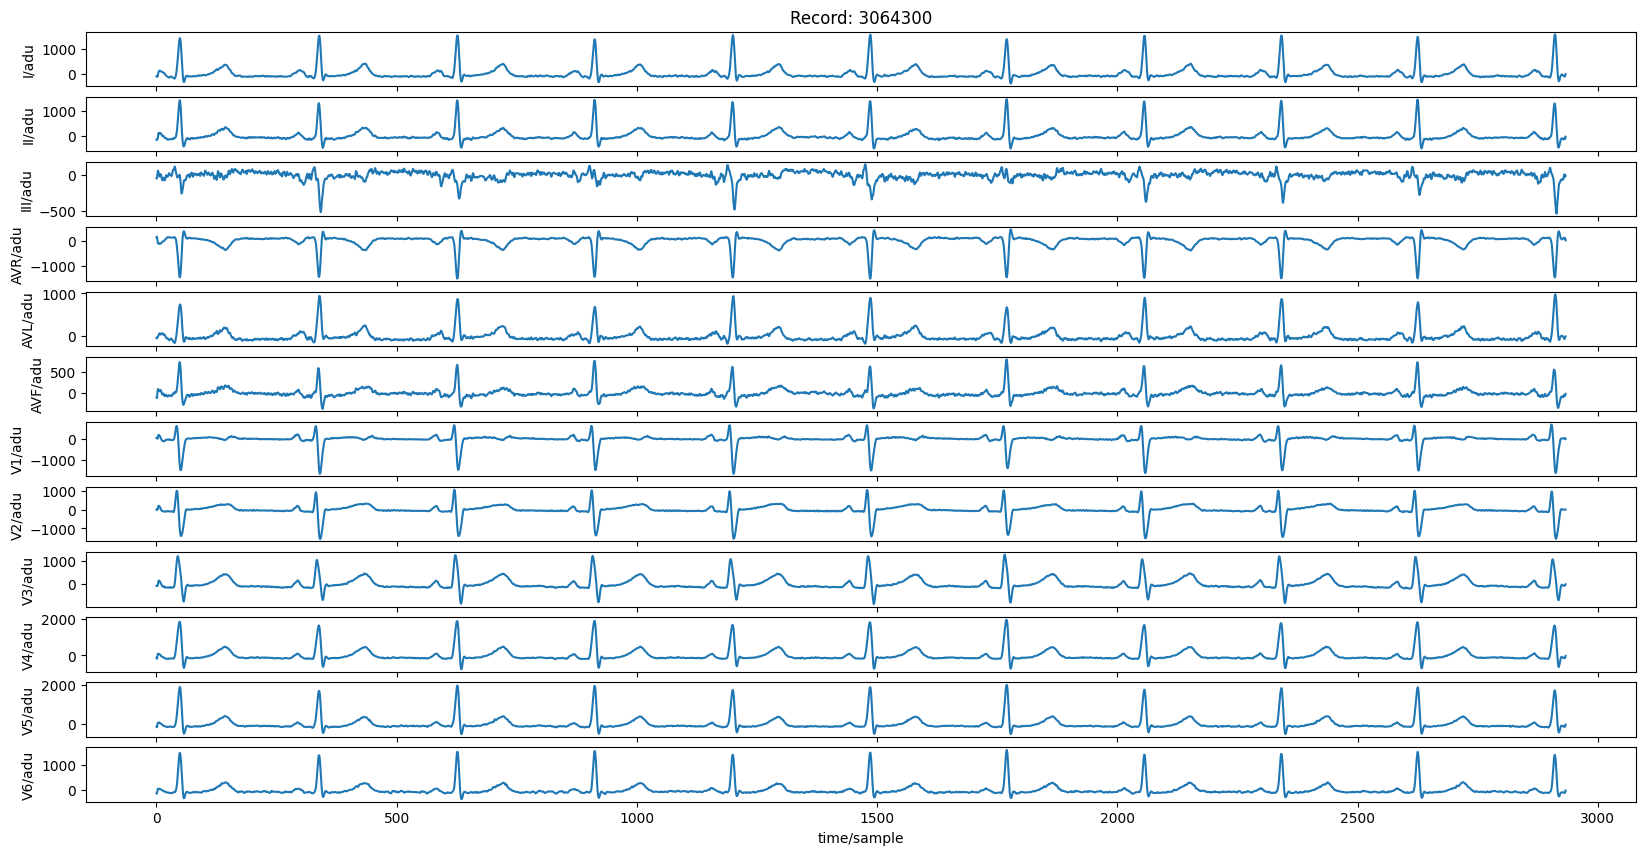

In [6]:
wfdb.plot_wfdb(record=wfdb.rdrecord(record, physical=False), figsize=(20, 10), time_units='samples')

## Creation of the dataset

<div>
<img src="res/ecg_features.jpg" width="500"/>
</div>

To effectively analyze the ECG time series, it is necessary to extract relevant features that capture specific characteristics of the signal. 

These features are defined by the occurrence of key fiducial points (P, Q, R, S, and T waves) as well as the duration of the segments between them. By measuring these temporal intervals, we can derive numerical representations of the ECG signal, which serve as inputs for classical machine learning (ML) algorithms to perform classification. 

Existing literature has demonstrated that the duration of these ECG patterns is strongly associated with the presence or absence of Chagas disease, making them critical features for the detection and diagnosis of the condition.

The feature extraction process is implemented in the `preprocessing.py` file, which utilizes the [NeuroKit2](https://neuropsychology.github.io/NeuroKit/) library to extract relevant characteristics from the ECG dataset. 

To ensure a comprehensive analysis, we initially extract all available features provided by the library. A subsequent feature selection process, performed later in the notebook, will identify the most informative features for classification, optimizing model performance and reducing potential redundancy in the dataset.

**Important**:

The original dataset provided for the challenge contains a **large volume of ECG recordings**, making it computationally expensive to process in its entirety. Working with the full dataset would have significantly slowed development and posed challenges when using online platforms such as Google Colab or Kaggle, which have resource limitations. To address this, **we opted to work with a partitioned subset of the data**, enabling more efficient experimentation and model development.

Additionally, the original dataset exhibited a notable class imbalance, with seropositive cases being significantly underrepresented compared to seronegative cases. By downsampling the dataset, we were able to balance the number of examples per class, ensuring a more effective and unbiased training process for our classification model.


In [7]:
data_path = Path("data")

if not (data_path / "signals_features.csv").exists():
    !python preprocessing.py --exams code15_hdf5/exams.csv --labels code15_hdf5/code15_chagas_labels.csv --train code15_wfdb/ --output data/ --seed 42 --jobs -1

df = pd.read_csv(data_path / "signals_features.csv")
to_be_dropped = df[df['ST_slope_mean'].isna()].exam_id.values.tolist()
df = df[~df['exam_id'].isin(to_be_dropped)].fillna(value=0)
df.drop('exam_id', axis=1, inplace=True)

# Exploratory Data Analysis

In [8]:
df.head()

,P_wave_duration_mean,P_wave_duration_std,P_wave_duration_min,P_wave_duration_max,PR_interval_mean,PR_interval_std,PR_interval_min,PR_interval_max,PR_segment_mean,PR_segment_std,...,HRV_Prc80NN,HRV_pNN50,HRV_pNN20,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,age,is_male,chagas
0,36.250000,10.856203,17.5,47.5,137.812500,39.830836,110.0,222.5,101.562500,40.903578,...,1110.0,55.555556,66.666667,865.0,1135.0,4.500000,250.0000,55,False,False
1,44.285714,4.498677,37.5,52.5,87.857143,0.944911,87.5,90.0,43.571429,4.531635,...,735.0,0.000000,12.500000,710.0,740.0,2.666667,0.0000,38,False,False
2,66.590909,5.156637,60.0,75.0,86.818182,8.069302,72.5,95.0,20.227273,10.808246,...,781.0,0.000000,8.333333,735.0,792.5,6.000000,23.4375,48,False,False
3,23.333333,7.180703,15.0,40.0,146.944444,16.619726,127.5,182.5,123.611111,17.682579,...,787.0,25.000000,66.666667,640.0,822.5,4.000000,148.4375,33,False,False
4,65.000000,25.248762,35.0,92.5,128.125000,68.446299,82.5,230.0,63.125000,62.861455,...,800.0,0.000000,16.666667,737.5,805.0,3.000000,46.8750,81,False,False


In [9]:
df.chagas.value_counts(normalize=True)

chagas
True     0.500153
False    0.499847
Name: proportion, dtype: float64

As we can see, the target variable is balanced among the two classes (seropositive and seronegative) with a 50% of the patients being seropositive and the other 50% being seronegative.

Cast the boolean columns to integers.

In [10]:
df['is_male'] = df['is_male'].astype(int)
df['chagas'] = df['chagas'].astype(int)

Exctract the numerical and categorical columns.

In [11]:
num_cols = [c for c in df.columns[:-1] if df[c].nunique() > 2]
cat_cols = [c for c in df.columns[:-1] if df[c].nunique() == 2]
print(f'Numeric: {num_cols}\nTotal: {len(num_cols)}')
print(f'Categorical: {cat_cols}\nTotal: {len(cat_cols)}')

Numeric: ['P_wave_duration_mean', 'P_wave_duration_std', 'P_wave_duration_min', 'P_wave_duration_max', 'PR_interval_mean', 'PR_interval_std', 'PR_interval_min', 'PR_interval_max', 'PR_segment_mean', 'PR_segment_std', 'PR_segment_min', 'PR_segment_max', 'QRS_duration_mean', 'QRS_duration_std', 'QRS_duration_min', 'QRS_duration_max', 'QT_interval_mean', 'QT_interval_std', 'QT_interval_min', 'QT_interval_max', 'ST_segment_mean', 'ST_segment_std', 'ST_segment_min', 'ST_segment_max', 'ST_slope_mean', 'ST_slope_std', 'ST_slope_min', 'ST_slope_max', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN', 'age']
Total: 48
Categorical: ['is_male']
Total: 1


Plot the distribution of the numerical columns.

A lot of them seems nornally distributed.

Furthermore, we have plotted the histogram of the numerical columns conditioned on the target variable. In this way we can see if the distribution of the numerical columns is different between the two classes (seropositive and seronegative).

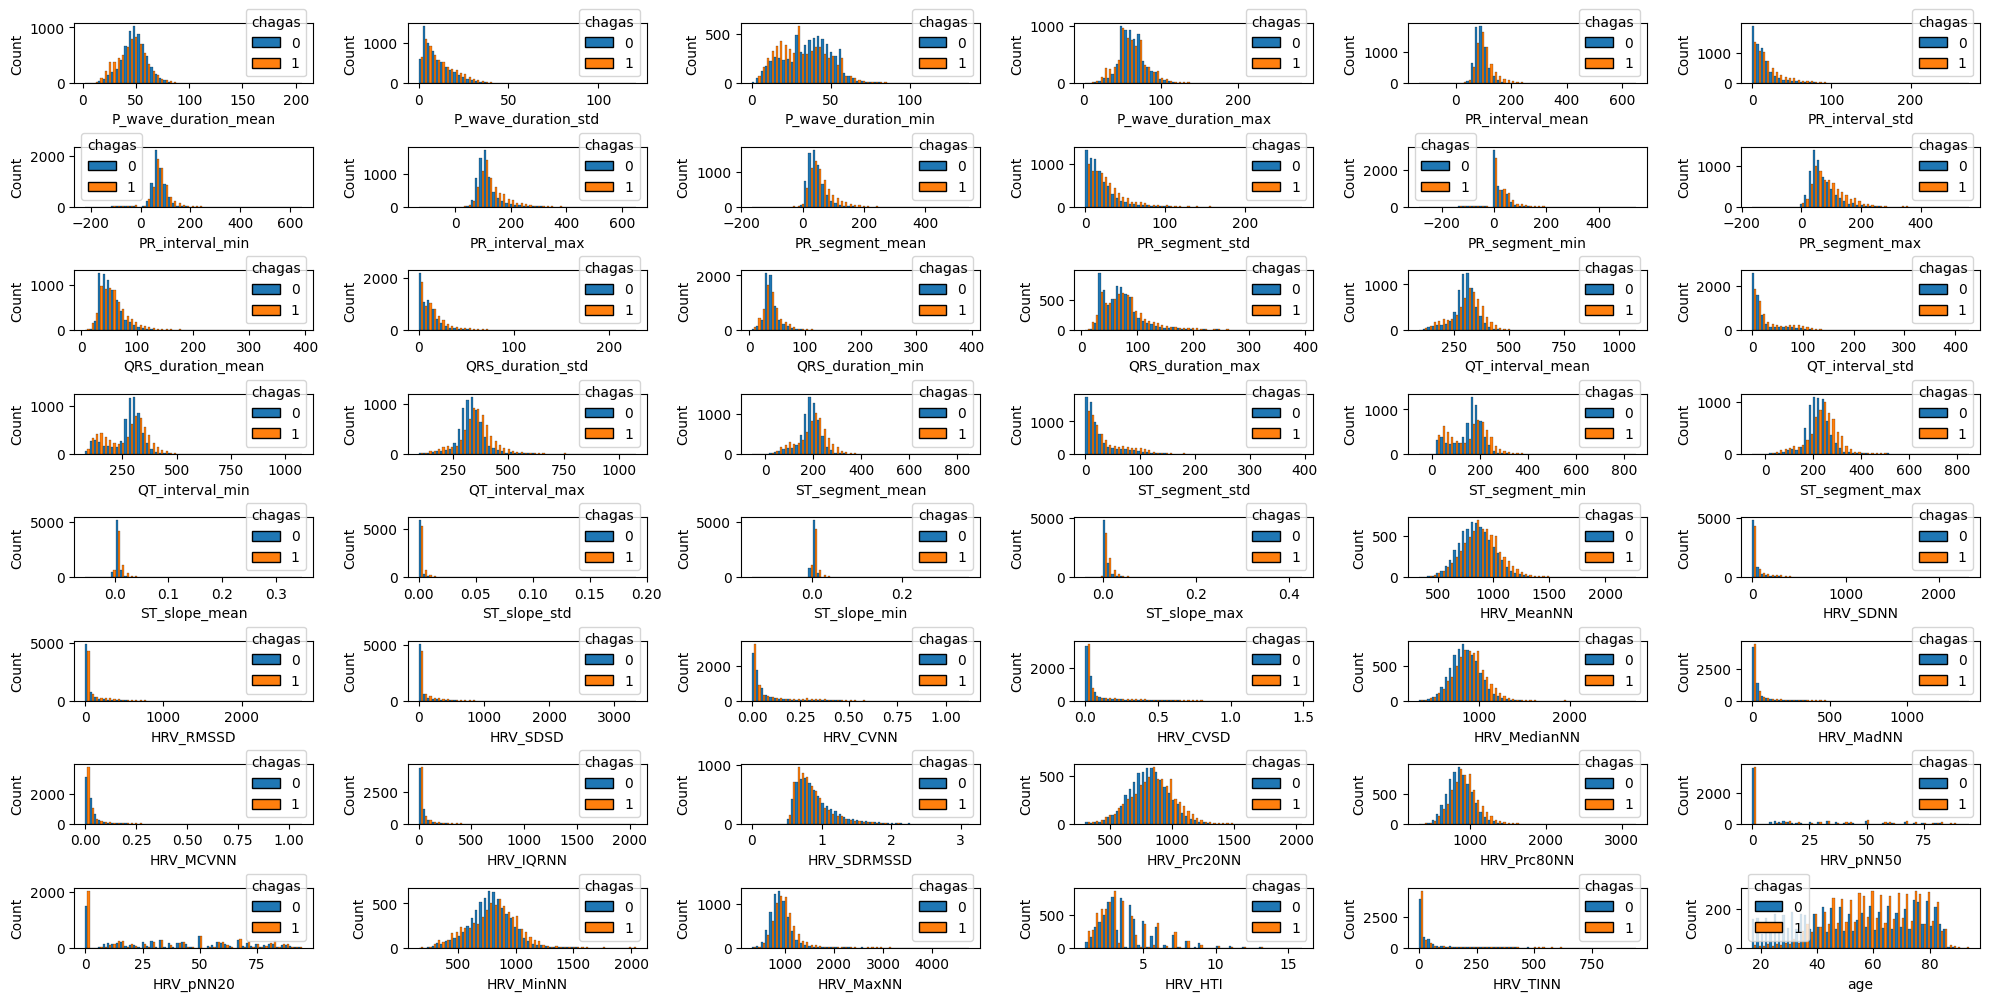

In [12]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20, 10))
for ax, cname in zip(axes.ravel(), num_cols):
    sn.histplot(data=df, x=cname, bins=50, stat="count", alpha=1, kde=False, multiple='dodge', ax=ax, hue='chagas')
plt.tight_layout()
plt.show()

The normally distributed columns could be:
- P_wave_duration_mean
- P_wave_duration_min
- P_wave_duration_max
- PR_interval_mean
- PR_interval_min
- PR_interval_max
- PR_segment_mean
- PR_segment_max
- QRS_duration_mean
- QRS_duration_min
- QRS_duration_max
- QT_interval_mean
- QT_interval_min
- QT_interval_max
- ST_segment_mean
- ST_segment_max
- HRV_MedianNN
- HRV_SDRMSSD
- HRV_Prc20NN
- HRV_Prc80NN
- HRV_MinNN
- HRV_MaxNN
- HRV_HTI

Other columns seems to be not normally distributed.

For the normally distributed columns, we can use the t-test to check if they are significantly different between the two classes. In this way we can see if the distribution of the numerical columns is different between the two classes (seropositive and seronegative).

In [13]:
pd.set_option('display.max_columns', None)
with_chagas = df[df['chagas'] == 1]
without_chagas = df[df['chagas'] == 0]

t_test_df = pd.DataFrame(columns=['column', 't_stat', 'p_value', 'is_significant'])
for col in ['P_wave_duration_mean', 'P_wave_duration_min', 'P_wave_duration_max', 'PR_interval_mean', 'PR_interval_min', 'PR_interval_max', 'PR_segment_mean', 'PR_segment_max', 'QRS_duration_mean', 'QRS_duration_min', 'QRS_duration_max', 'QT_interval_mean', 'QT_interval_min', 'QT_interval_max', 'ST_segment_mean', 'ST_segment_max', 'HRV_MedianNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI']:
    if col != 'chagas':
        test_result = sp.stats.ttest_ind(with_chagas[col], without_chagas[col], equal_var=False)
        t_test_df.loc[len(t_test_df)] = [col, test_result[0], test_result[1], test_result[1] < 0.05]

In [14]:
t_test_df.sort_values(by='p_value')

,column,t_stat,p_value,is_significant
6,PR_segment_mean,20.819895,1.633643e-94,True
7,PR_segment_max,20.634896,4.930207e-93,True
5,PR_interval_max,18.113069,2.226532e-72,True
21,HRV_MaxNN,15.886669,2.847833e-56,True
3,PR_interval_mean,15.732206,3.498921e-55,True
0,P_wave_duration_mean,-15.235253,5.901368e-52,True
15,ST_segment_max,14.821371,2.896867e-49,True
17,HRV_SDRMSSD,-14.733790,9.797298e-49,True
19,HRV_Prc80NN,13.986132,4.023160e-44,True
1,P_wave_duration_min,-13.572657,1.116486e-41,True


All the columns which seem to be normally distributed are significantly different between the two classes. 

Using the t-test we can see if the mean of the two distributions are different each other. In this sense, we can see if the distribution of the numerical columns is different between the two classes (seropositive and seronegative) under all the columns (since the p-value is less than 0.05). This means that we reject the null hypothesis thus concluding that there is enough evidence to say that the mean of the two distributions are different each other.
The `equal_var=False` is used to account for the fact that the two distributions might have different variances.

Other columns are not normally distributed, so the t-test is not appropriate and will not be considered.

Plot the distribution of the categorical columns.

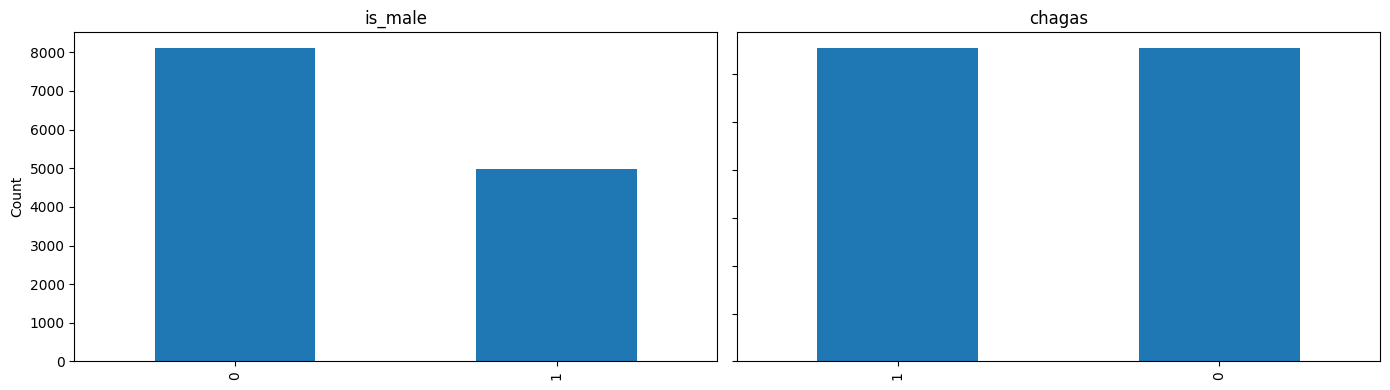

In [15]:
_, axes = plt.subplots(nrows=1, ncols=2)
for i, cname in enumerate(cat_cols + ['chagas']):
    df[cname].value_counts().plot(kind='bar', ax=axes[i], figsize=figsize, title=cname, ylabel='Count', xlabel='', sharey=True)

plt.tight_layout()

From the plot we can see that the distribution of the categorical columns is different between the two classes. There are more females that males in the dataset. The target variable is balanced as the number of seropositive and seronegative are almost the same.

Plot the distribution of the target variable conditioned on the categorical columns.

In [16]:
df.groupby('is_male')['chagas'].mean()

is_male
0    0.512821
1    0.479477
Name: chagas, dtype: float64

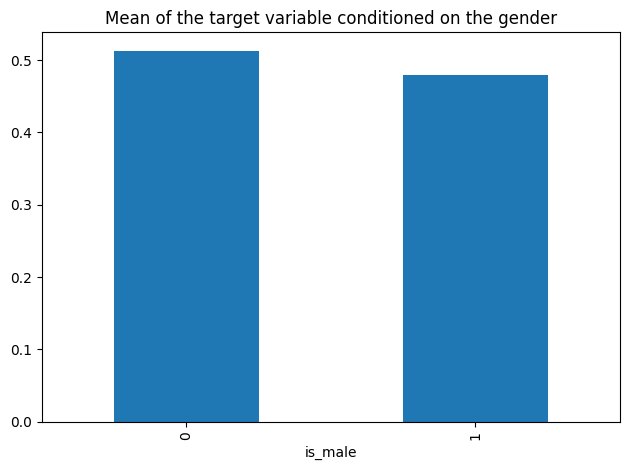

In [17]:
df.groupby('is_male')['chagas'].mean().plot.bar(title='Mean of the target variable conditioned on the gender')
plt.tight_layout()

As we can see, the mean of the target variable is almost the same for the two classes. This means that the gender is not a good predictor of the target variable.

Now, we can plot the distribution of the numerical columns conditioned by the target variable. In this way we can see if there are some numerical columns that show a different distribution between the two classes hence being good predictors of the target variable or showing some interesting patterns (or correlations).

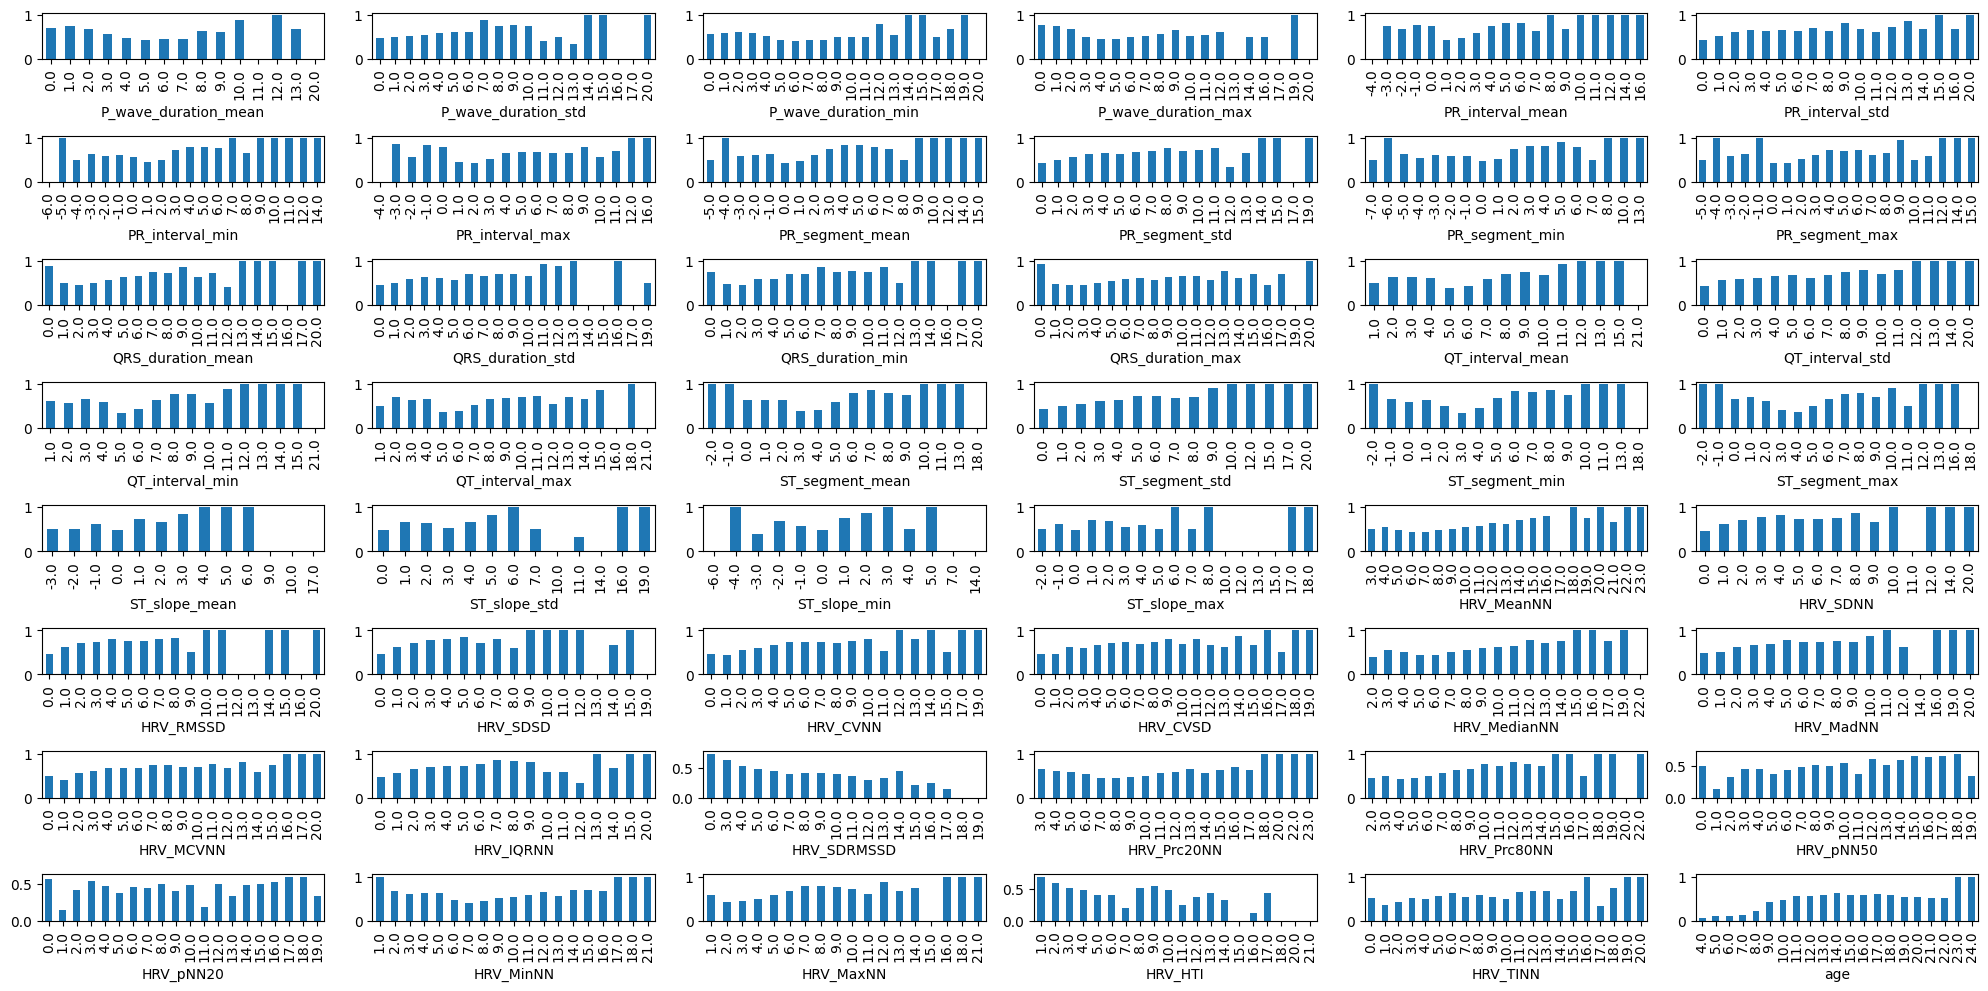

In [18]:
_, axes = plt.subplots(nrows=8, ncols=6, figsize=(20,10))
for ax, cname in zip(axes.ravel(), num_cols):
    bin_size = (df[cname].max() - df[cname].min()) / 20
    df['chagas'].groupby(df[cname] // bin_size).mean().plot.bar(ax=ax)
plt.tight_layout()

Among all the numerical columns, the ones that show some kind of linear correlation with the target variable are age, HRV_MeanNN, ST_segment_std, QT_interval_std, ST_slope_mean, PR_interval_std, HRV_SDRMSSD, etc.

There are also some columns that show a non-linear correlation with the target variable (e.g. P_wave_duration_mean).

This insights can be confirmed by the correlation matrix.

We will plot the correlation matrix of the numerical columns using the Pearson correlation coefficient. In this way we can see if there are some numerical columns that show a linear relationship with the target variable.

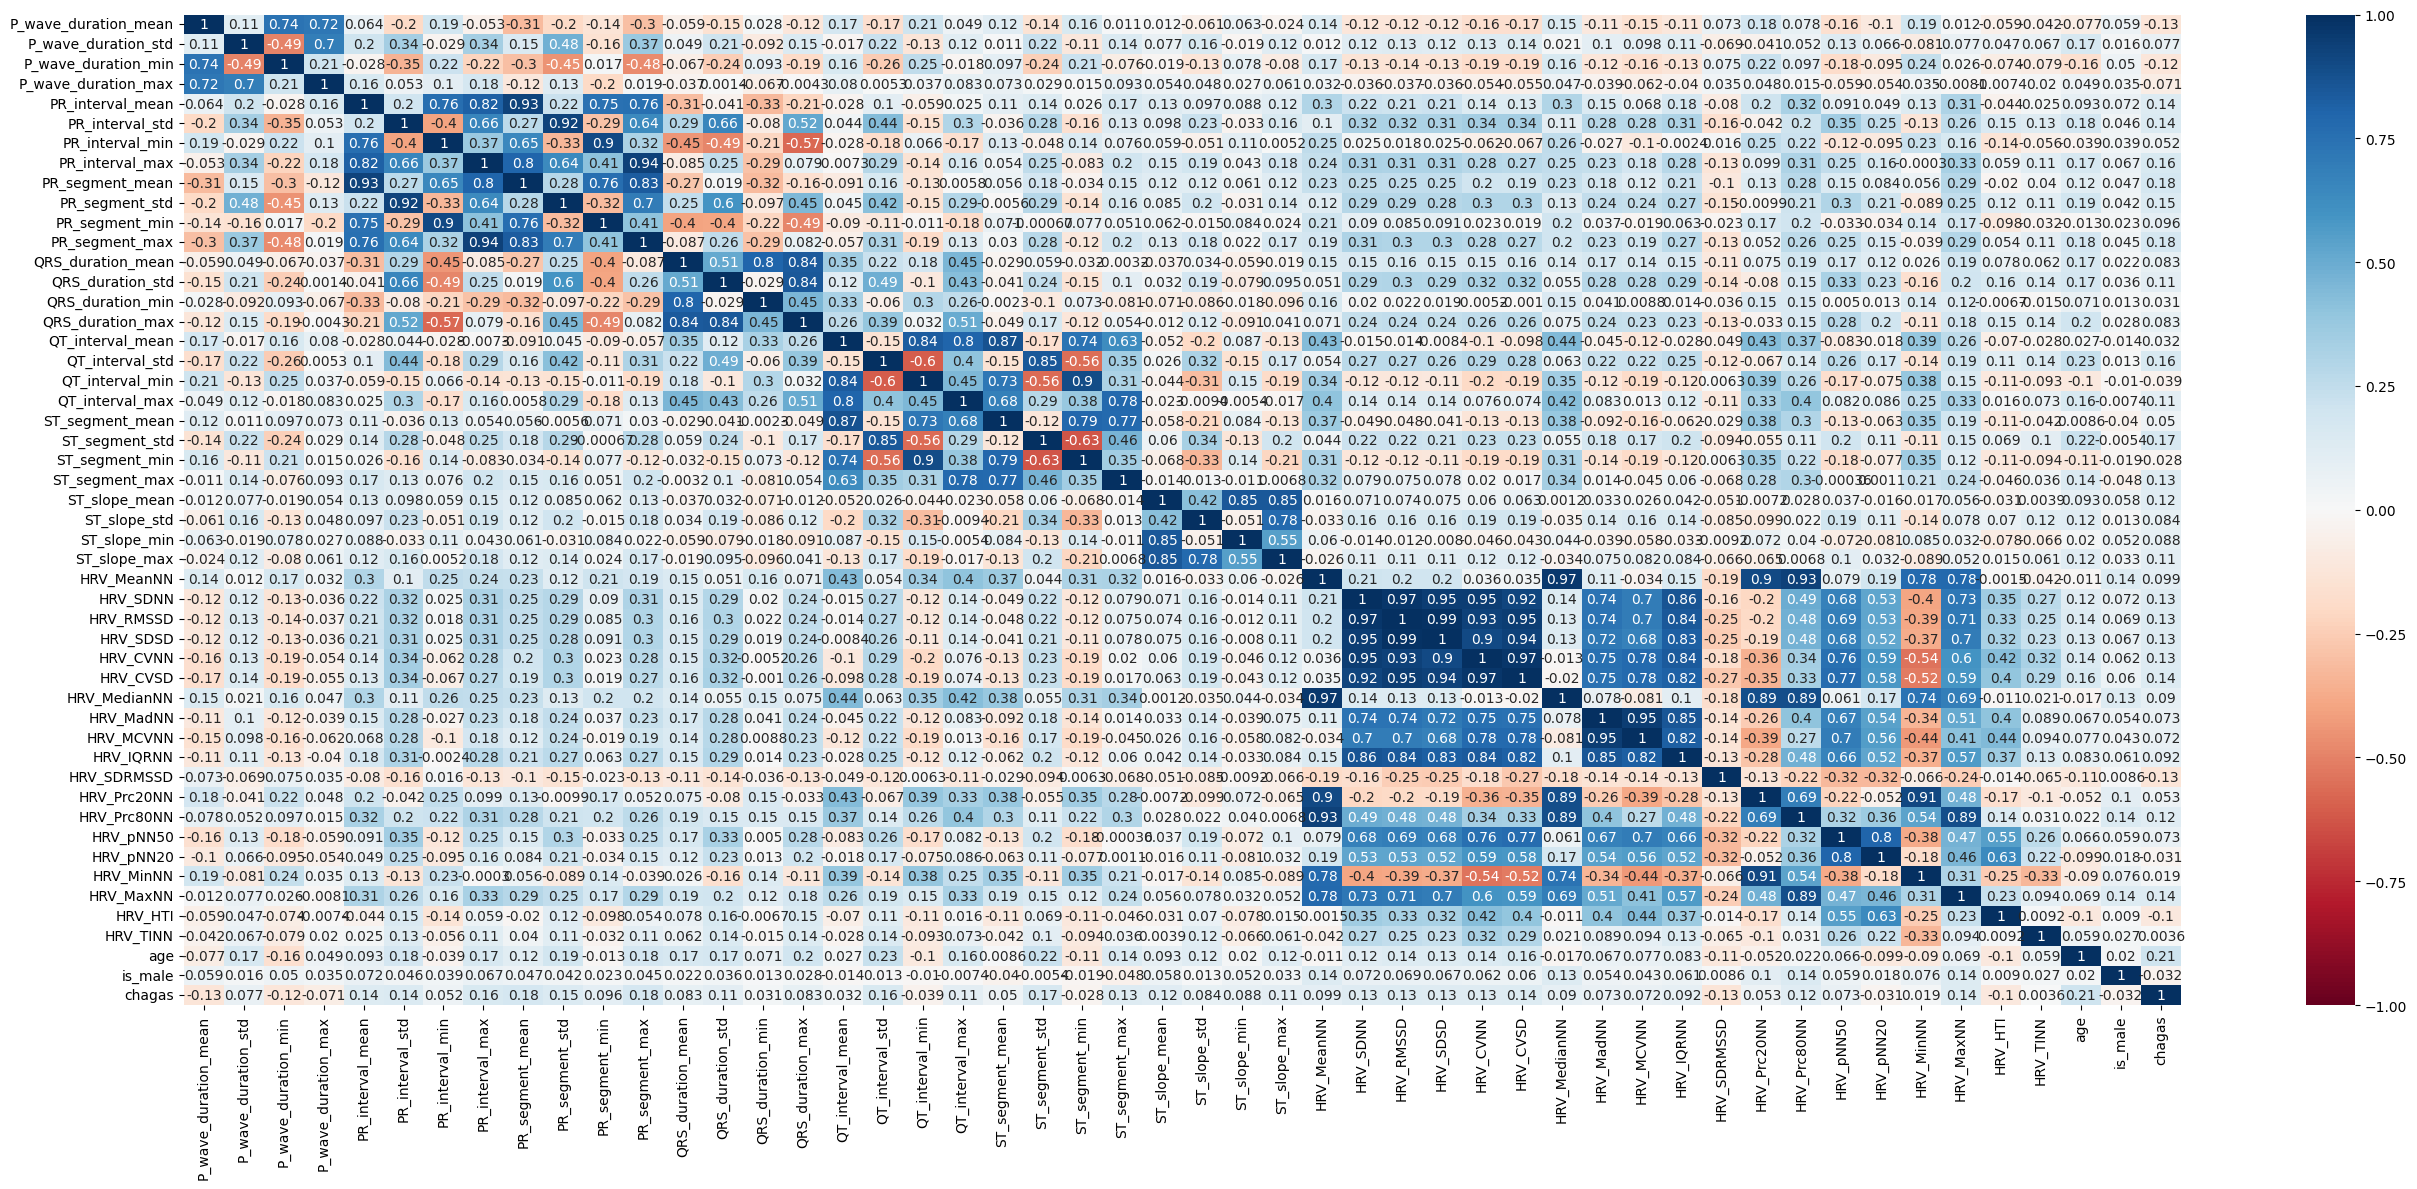

In [66]:
plt.figure(figsize=(27,12))
sn.heatmap(df.corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

As we can see there are some slight correlations between the numerical columns and the target variable. Indeed they are not very strong but they are there. Just to mention a few:
- age
- P_wave_duration_mean
- P_wave_duration_min
- PR_interval_mean
- PR_interval_std
- HRV_HTI

However we can notice that there are strong correlations between some variables (ST_slope_mean and ST_slope_min and max). Since Logistic Regression is a linear model which might be affected by multicollinearity, we will drop the ST_slope_min and ST_slope_max columns.

In [71]:
test = df.drop(columns=['ST_slope_min','ST_slope_max','HRV_SDNN','HRV_SDSD','HRV_CVNN','HRV_CVSD','HRV_MadNN','HRV_MCVNN','HRV_IQRNN','HRV_Prc20NN','HRV_Prc80NN','HRV_pNN50','HRV_pNN20','PR_interval_min','PR_interval_max','PR_interval_std','PR_interval_mean','HRV_MaxNN','HRV_MeanNN','HRV_MinNN','HRV_SDRMSSD','QRS_duration_min','QRS_duration_max','PR_segment_max','QT_interval_min','QT_interval_max','QT_interval_mean','ST_segment_min','P_wave_duration_min','P_wave_duration_max','ST_segment_max','PR_segment_min','PR_segment_std','ST_segment_std'])

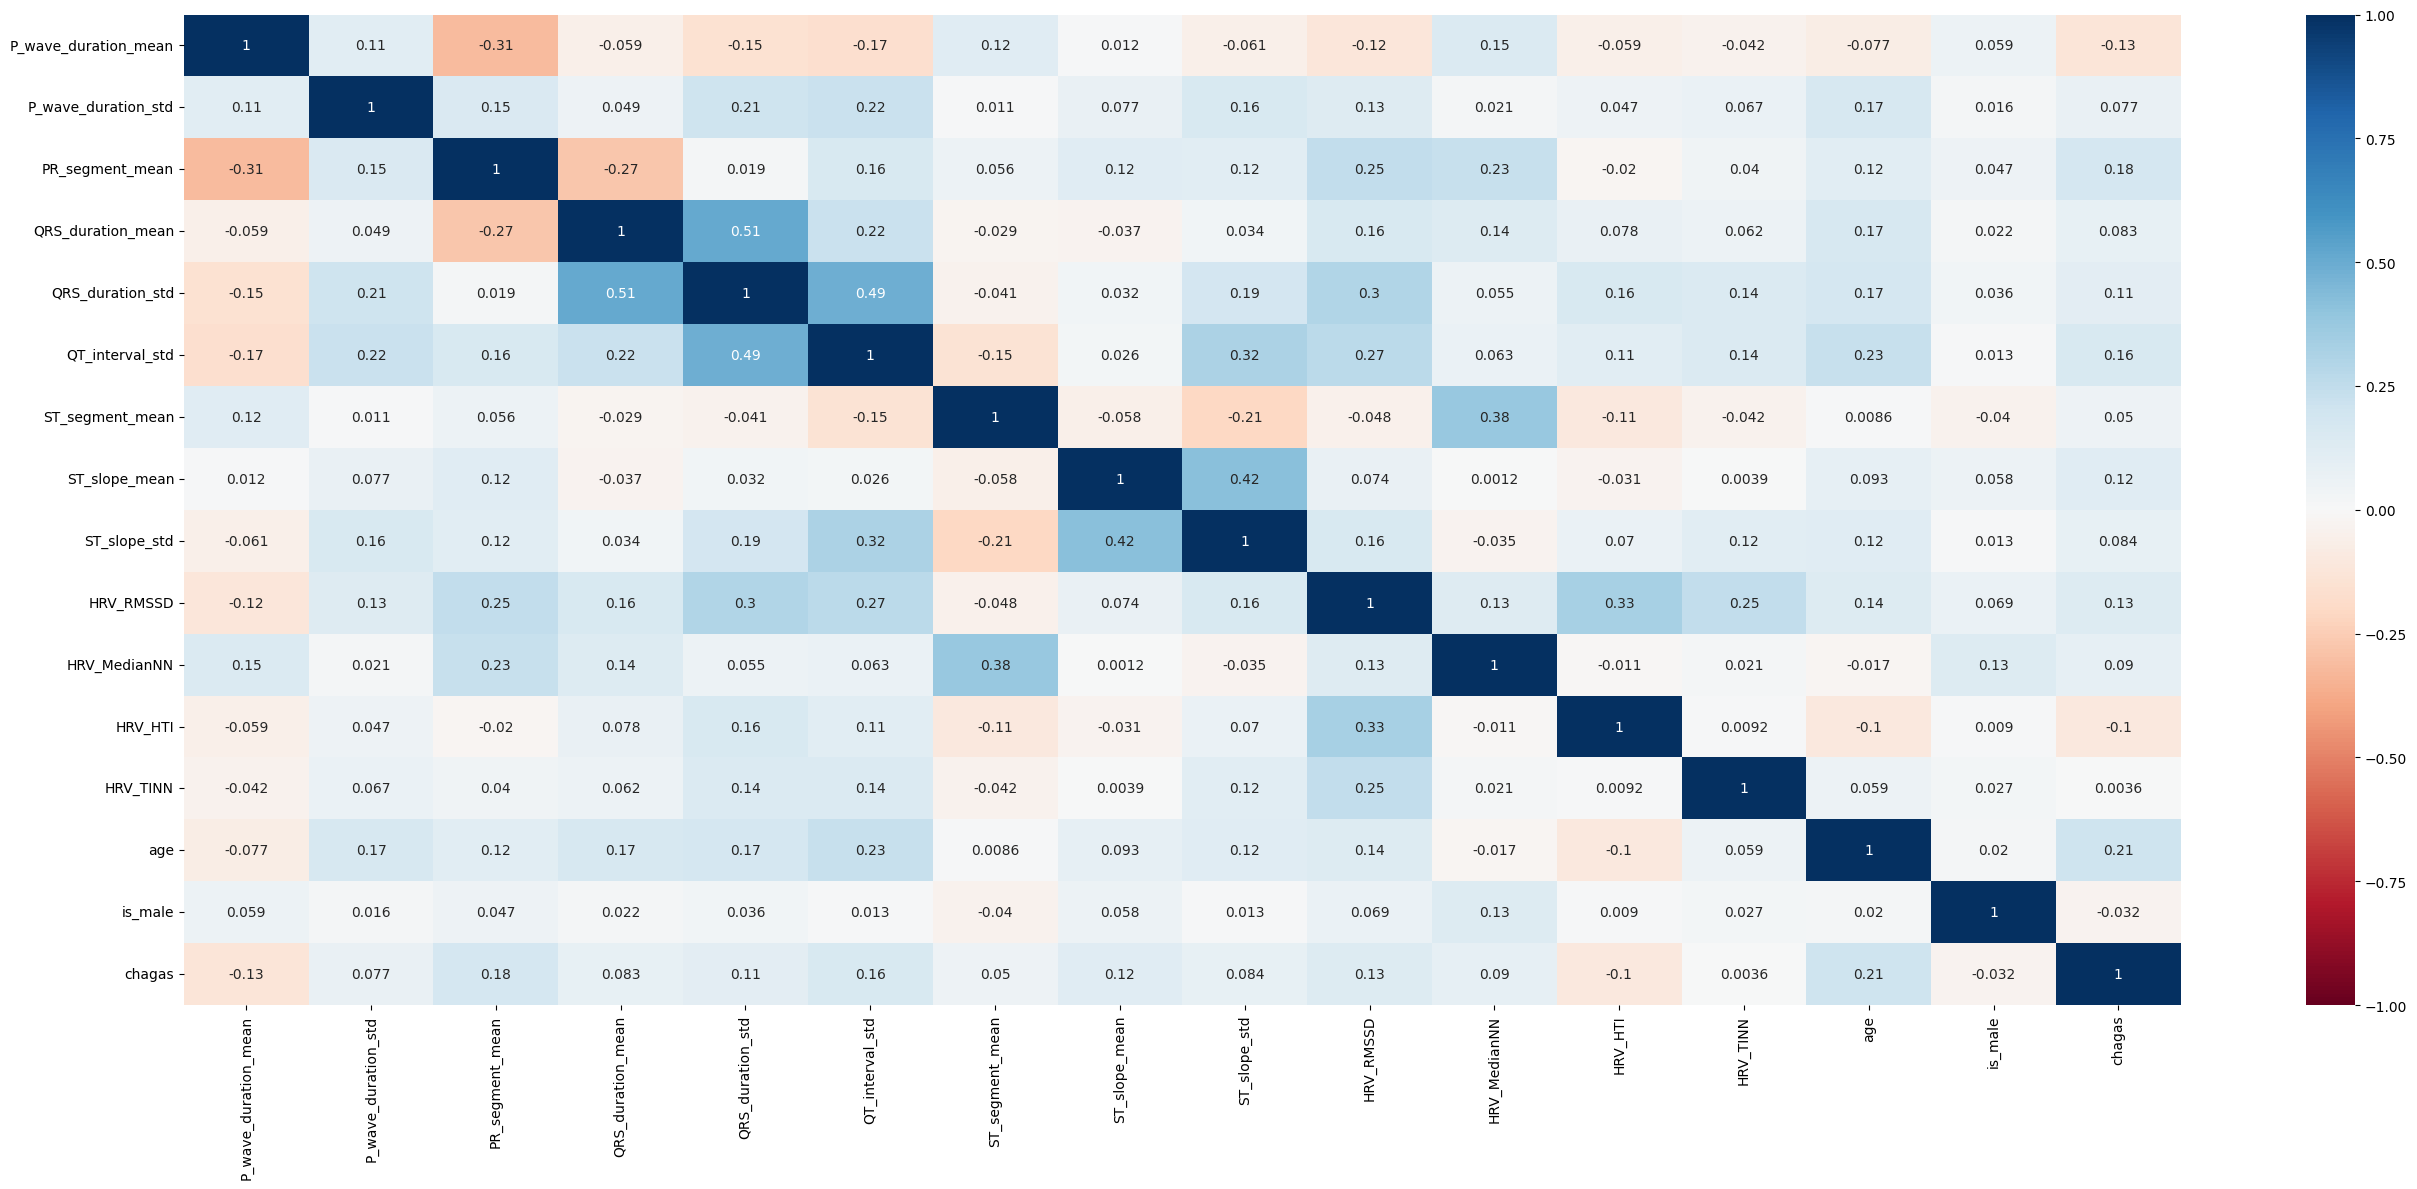

In [72]:
plt.figure(figsize=(27,12))
sn.heatmap(test.corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

### A more in-depth analysis of the data

First of all, our interest went to the heart rate variability (HRV) in different age groups. We divided the age into 4 groups (using qcut) and plotted the HRV_HTI in each group.

`HRV_HTI` is the triangular index, measuring the total number of RR intervals divided by the height of the RR intervals. If the number of total RR intervals is the same, then the HRV_HTI is higher if the RR intervals are more regular (since the majority of the RR intervals are close to the mean).

To better identify potential differences between seropositive and seronegative patients, we plotted the violin plot of the HRV_HTI in each age group with the hue being the target variable.

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)


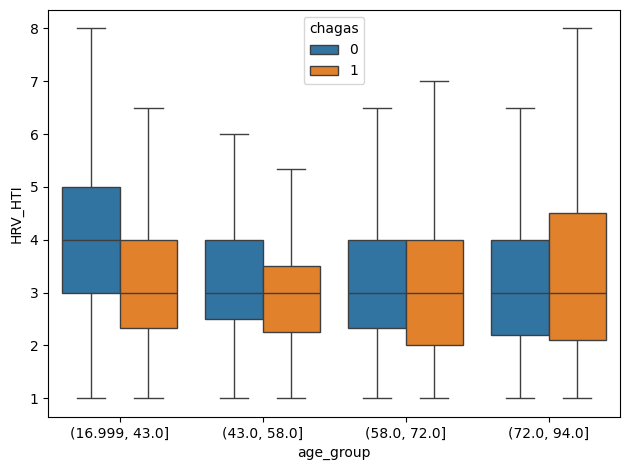

In [80]:
df['age_group'] = pd.qcut(df['age'], q=4)
sn.boxplot(x='age_group', y='HRV_HTI', hue='chagas', data=df, showfliers=False)
plt.tight_layout()
plt.show()

The HRV_HTI index is notably higher among young patients who are seronegative for Chagas.
This indicates that younger individuals without Chagas disease tend to have a more regular heart rate, as reflected by their higher HRV_HTI values.
However, from middle age onward, the HRV_HTI values converge for both groups. This can be explained by two main factors:
- With advancing age, the heart's electrical activity naturally becomes more irregular, which may lower the HRV_HTI in seronegative middle-aged and older patients.
- Chagas disease further disrupts heart tissue, leading to a more irregular heart rate and consequently a reduced HRV_HTI in seropositive middle-aged and older patients.

While the HRV_HTI index is a reliable predictor of the target variable in young patients, its predictive power diminishes with age.

In order to assess for arrhythmia, we plotted the HRV_SDSD in each age group with the hue being the target variable.

/tmp/ipykernel_10924/2734694170.py:1: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  age_groups = df['age_group'].cat.categories if pd.api.types.is_categorical_dtype(df['age_group']) else sorted(df['age_group'].unique())


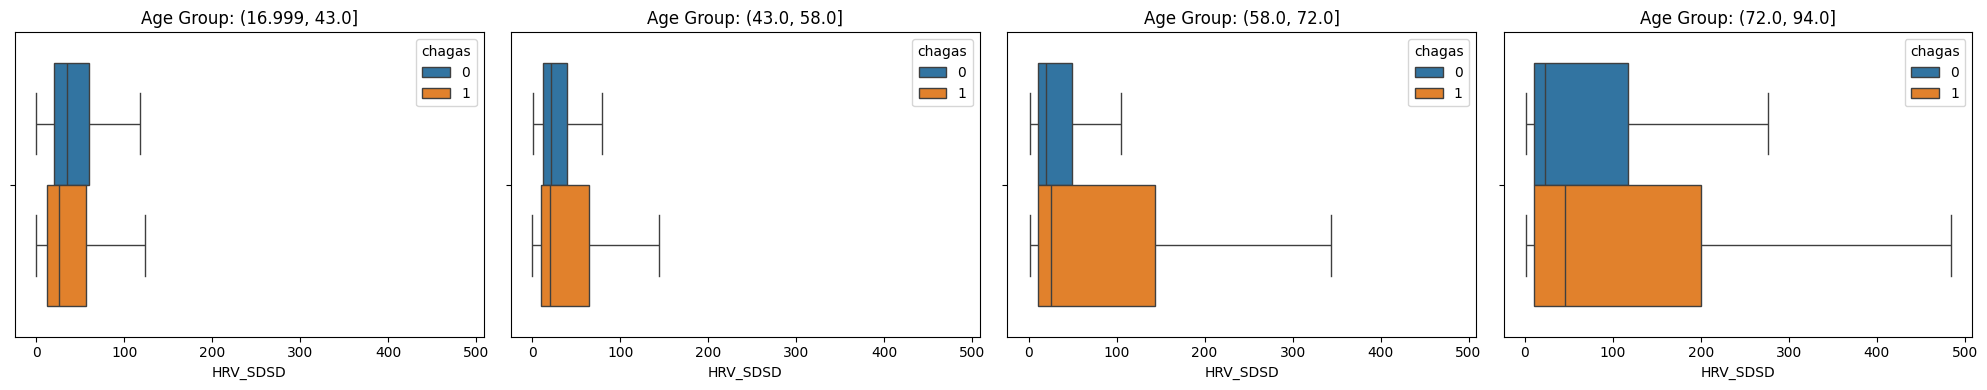

In [81]:
age_groups = df['age_group'].cat.categories if pd.api.types.is_categorical_dtype(df['age_group']) else sorted(df['age_group'].unique())
n_groups = len(age_groups)
fig, axes = plt.subplots(1, n_groups, figsize=(5 * n_groups, 4), sharex=True, sharey=True)

for ax, group in zip(axes, age_groups):
    subset = df[df['age_group'] == group]
    sn.boxplot(data=subset, x='HRV_SDSD', hue='chagas', ax=ax, showfliers=False)
    ax.set_title(f'Age Group: {group}')

plt.tight_layout()
plt.show()

The findings are consistent with https://doi.org/10.1016/0002-8703(83)90529-X since:
* Starting from middle age, the HRV_SDSD is higher for the seropositive patients indicating a more irregular heart rate which increases with age.
* For young patients, the IQR is almost the same indicating that the HRV_SDSD is not a good predictor of the target variable for young patients.

Thus elderly patients have an increased risk of arrhythmia and the HRV_SDSD values are higher for the seropositive patients.

We also plotted the QRS_duration_mean in each age group with the hue being the target variable.

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)


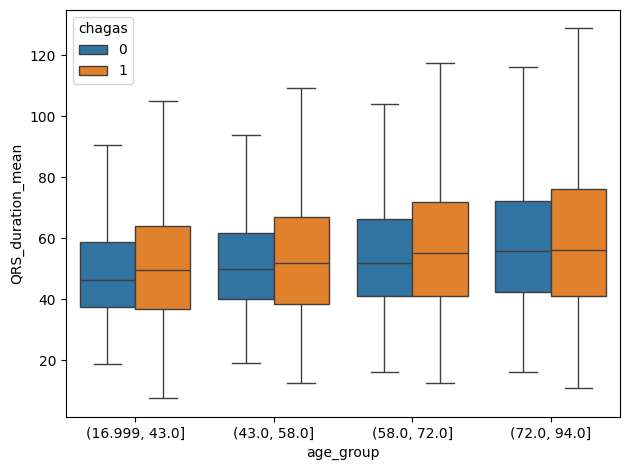

In [82]:
df['age_group'] = pd.qcut(df['age'], q=4)
sn.boxplot(x='age_group', y='QRS_duration_mean', hue='chagas', data=df, showfliers=False)
plt.tight_layout()
plt.show()

The QRS_duration_mean confirms part of the previous analysis.
* For young patients, the QRS_duration_mean is higher for the seropositive patients indicating a more irregular heart rate.
* For almost all the age groups (including young ones), the QRS_duration_mean is higher for the seropositive patients indicating a more irregular heart rate. However, the difference becomes negligible for the oldest age group. This is consistent with the previous analysis that elderly patients are more difficult to classify due to the natural decay of electrical efficiency of heart tissue.

This is consistent with the findings of:
* Maguire JH, Mott KE, Lehman JS, Hoff R, Muniz TM, Guimarães AC, Sherlock I, Morrow RH. Relationship of electrocardiographic abnormalities and seropositivity to Trypanosoma cruzi within a rural community in northeast Brazil. Am Heart J. 1983 Feb;105(2):287-94. doi: https://doi.org/10.1016/0002-8703(83)90529-X. PMID: 6337465.
* Williams-Blangero S, Magalhaes T, Rainwater E, Blangero J, Corrêa-Oliveira R, Vandeberg JL. Electrocardiographic characteristics in a population with high rates of seropositivity for Trypanosoma cruzi infection. Am J Trop Med Hyg. 2007 Sep;77(3):495-9. doi: https://doi.org/10.4269/ajtmh.2007.77.495. PMID: 17827366

We tried to confirm the QRS intuition by plotting the PR_segment_mean and PR_interval_mean in each age group with the hue being the target variable.

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)


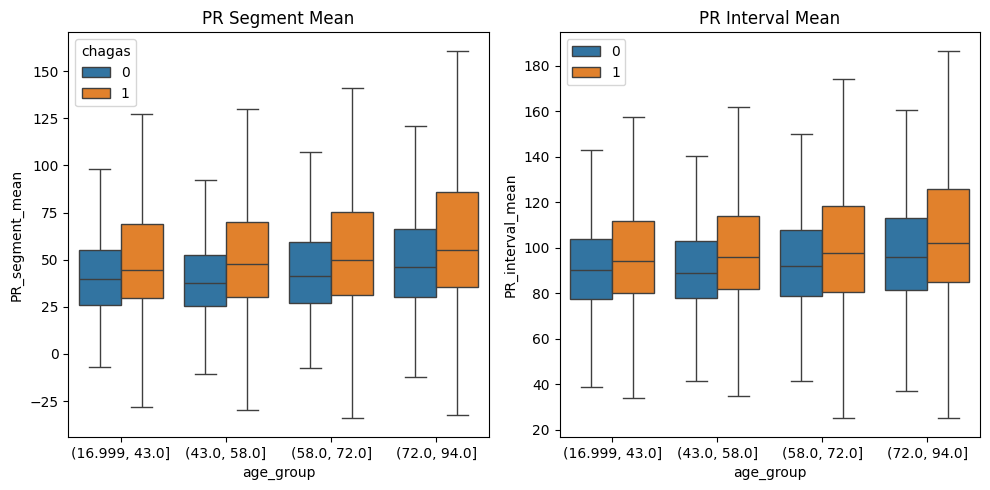

In [83]:
df['age_group'] = pd.qcut(df['age'], q=4)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.boxplot(x='age_group', y='PR_segment_mean', hue='chagas', data=df, showfliers=False)
plt.title('PR Segment Mean')
plt.subplot(1, 2, 2)
sn.boxplot(x='age_group', y='PR_interval_mean', hue='chagas', data=df, showfliers=False)
plt.title('PR Interval Mean')
plt.legend()
#plt.grid(axis='y')
plt.tight_layout()
plt.show()

In both the Segment mean and the Interval mean, we can see that the seropositive patients have a higher value of the PR segment and interval mean at all the age groups. This suggests that with the PR segment and interval mean we can identify the seropositive patients since the difference of their mean is quite high. Moreover, the IQR of the seropositive patients is higher than the seronegative patients, which suggests that Chagas disease affects the PR segment and interval mean.

Following the intuition of https://doi.org/10.1016/0002-8703(83)90529-X, we plotted the PR_interval_mean by each age group and the target variable when the PR_interval_mean is greater than 0.17 and 0.20.

If the PR interval is greater than 0.20 then there is a strong correlation with Chagas disease at all age groups.

/tmp/ipykernel_10924/1021676647.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sn.barplot(df[df['PR_interval_mean'] / 1000 >= 0.17].groupby('age_group')['chagas'].value_counts().reset_index(), x='age_group', y='count', hue='chagas')
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered in cast
  return np.array(self, dtype=dtype, copy=copy)
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/pandas/core/arrays/base.py:725: RuntimeWarning: invalid value encountered i

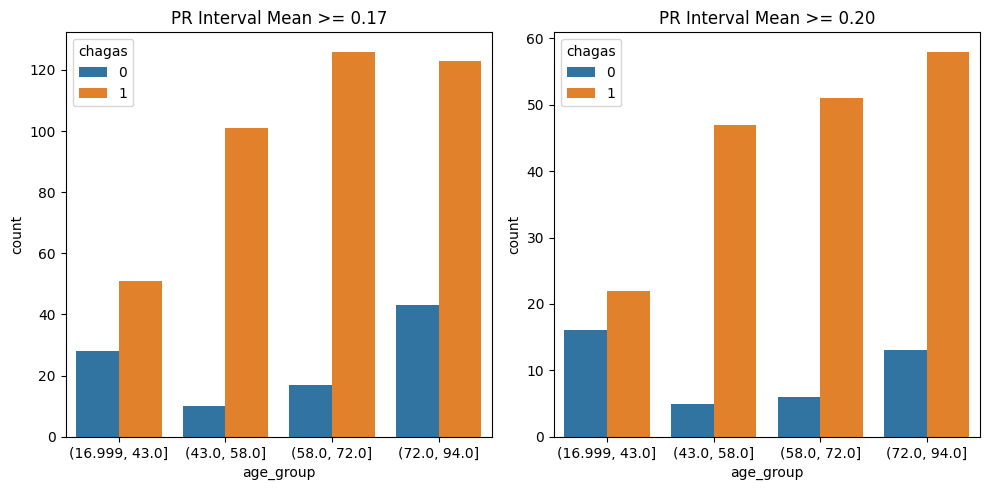

In [84]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sn.barplot(df[df['PR_interval_mean'] / 1000 >= 0.17].groupby('age_group')['chagas'].value_counts().reset_index(), x='age_group', y='count', hue='chagas')
plt.title('PR Interval Mean >= 0.17')
plt.subplot(1, 2, 2)
sn.barplot(df[df['PR_interval_mean'] / 1000 >= 0.20].groupby('age_group')['chagas'].value_counts().reset_index(), x='age_group', y='count', hue='chagas')
plt.title('PR Interval Mean >= 0.20')
plt.tight_layout()
plt.show()


At all the age groups, the PR interval mean is higher for the seropositive patients. This aligns with the findings of the previous articles suggesting that the PR interval mean is a good predictor of the target variable (confirmed by the literature).

### Standardization of the data

Split the data into training and testing sets. Shuffle the data and stratify the target variable.

Apply the StandardScaler to the numerical columns.

In [85]:
X, y = df.drop(columns=['chagas', 'age_group'], axis=1), df['chagas']

X['age'] = ((X['age'] - X['age'].min()) / (X['age'].max() - X['age'].min())).astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y, shuffle=True)
scaler = StandardScaler()
X_train.iloc[:, :-2] = scaler.fit_transform(X_train.iloc[:, :-2])
X_test.iloc[:, :-2] = scaler.transform(X_test.iloc[:, :-2])

In [89]:
results_dict = {}

def print_results(model, y_test, y_pred, y_pred_proba):
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred)
    f_beta = fbeta_score(y_test, y_pred, beta=0.5)
    print(f'Accuracy: {acc:.4f}')
    print(f'ROC-AUC: {auc:.4f}')
    print(f'F1-score: {f1:.4f}')
    print("F-beta score", f_beta)
    sn.heatmap(confusion_matrix(y_test, y_pred, labels=[0, 1], normalize="all"), annot=True, cmap='viridis')
    plt.tight_layout()
    plt.show()
    return {'acc': acc, 'auc': auc, 'f1': f1, 'f_beta': f_beta}

# Logistic Regression

In [131]:
base_est = LogisticRegression(penalty='l1', solver='saga', random_state=SEED)
param_grid={'C': 1. / np.linspace(1e-1, 1e4, 100)}
gscv = GridSearchCV(base_est, param_grid=param_grid, scoring='roc_auc')
gscv.fit(X_train, y_train)
lr, lr_params = gscv.best_estimator_, gscv.best_params_

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached w

In [136]:
lr_score_cv, lr_score_test = gscv.best_score_, roc_auc_score(y_test, lr.predict_proba(X_test)[:, 1])
print(f'AUC score for C={lr_params["C"]:.2f}: {lr_score_cv:.2f} (cross-validation), {lr_score_test:.2f} (test)')

AUC score for C=10.00: 0.75 (cross-validation), 0.75 (test)


Accuracy: 0.6817
ROC-AUC: 0.7457
F1-score: 0.6711
F-beta score 0.684931506849315


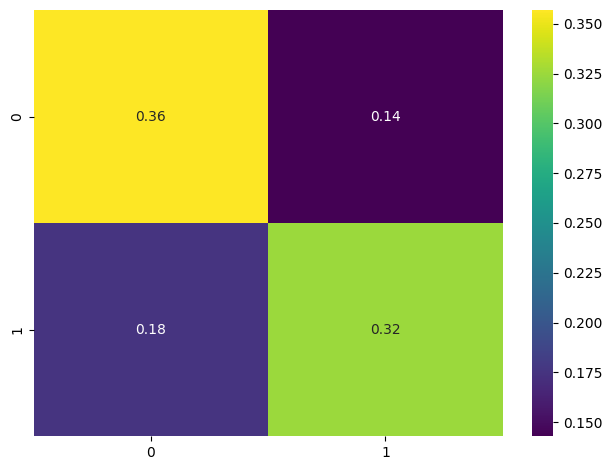

In [137]:
results_dict['Logistic Regression'] = print_results(lr, y_test, lr.predict(X_test), lr.predict_proba(X_test)[:, 1])

In [138]:
pd.Series( lr.predict_proba(X_test)[:, 1]).describe()

count    2617.000000
mean        0.499581
std         0.206676
min         0.044363
25%         0.339557
50%         0.480396
75%         0.645786
max         0.997948
dtype: float64

<Axes: >

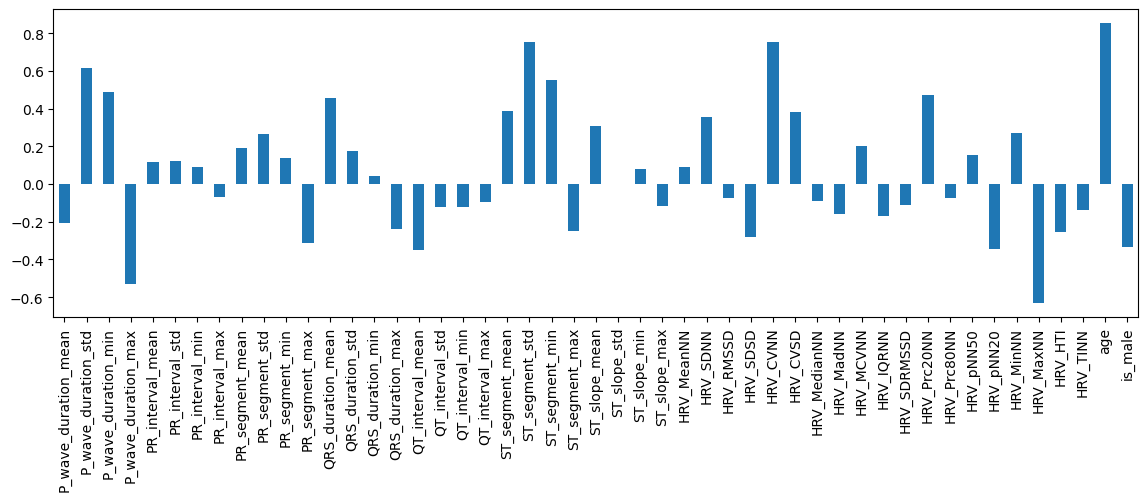

In [139]:
lr_coefs = pd.Series(index=X.columns, data=lr.coef_[0])
lr_coefs.plot(kind='bar', figsize=figsize)

# XGBoost

In [140]:
base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv = GridSearchCV(base_est, param_grid=param_grid)
gscv.fit(X_train, y_train)
xbm, xbm_params = gscv.best_estimator_, gscv.best_params_

In [141]:
xbm_score_test = roc_auc_score(y_test, xbm.predict_proba(X_test)[:, 1])
print(f'AUC score for max_depth={xbm_params["max_depth"]}, n_estimators={xbm_params["n_estimators"]}, reg_lambda={xbm_params["reg_lambda"]:.2f}: {xbm_score_test:.2f} (test)')

AUC score for max_depth=4, n_estimators=40, reg_lambda=100.00: 0.78 (test)


Accuracy: 0.7050
ROC-AUC: 0.7813
F1-score: 0.7145
F-beta score 0.7011177239076789


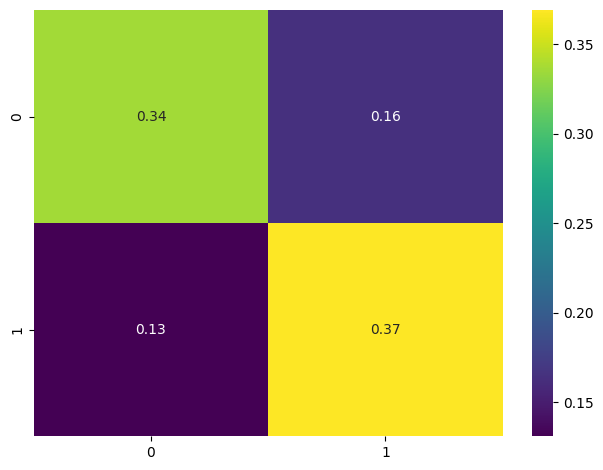

In [142]:
results_dict['XGBoost'] = print_results(xbm, y_test, y_pred=xbm.predict(X_test), y_pred_proba=xbm.predict_proba(X_test)[:, 1])

In [65]:
#plt.figure(figsize=(20, 20))
#xgboost.plot_tree(xbm, ax=plt.gca(), num_trees=0)

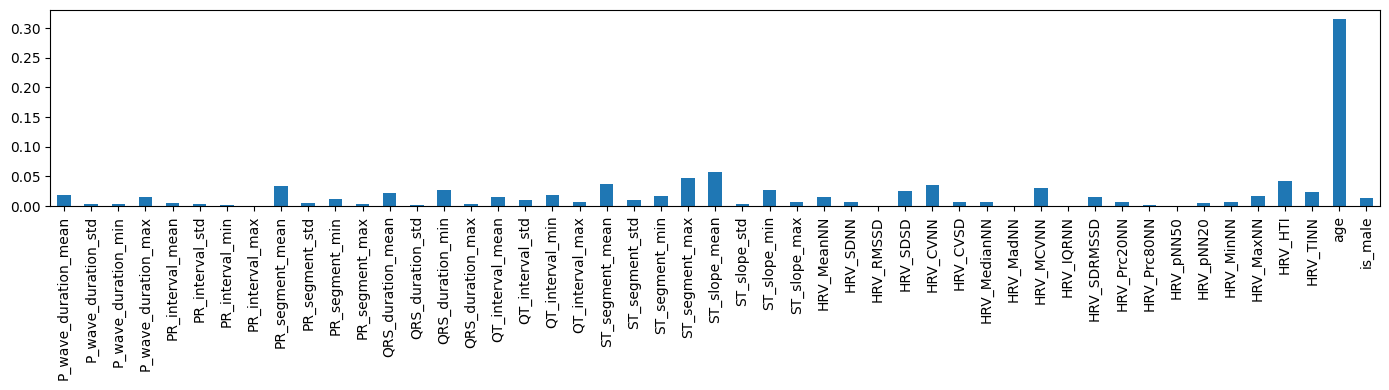

In [143]:
xbm_imp = pd.Series(index=X.columns, data=xbm.feature_importances_)
xbm_imp.plot(kind='bar', figsize=figsize)
plt.tight_layout()
plt.show()

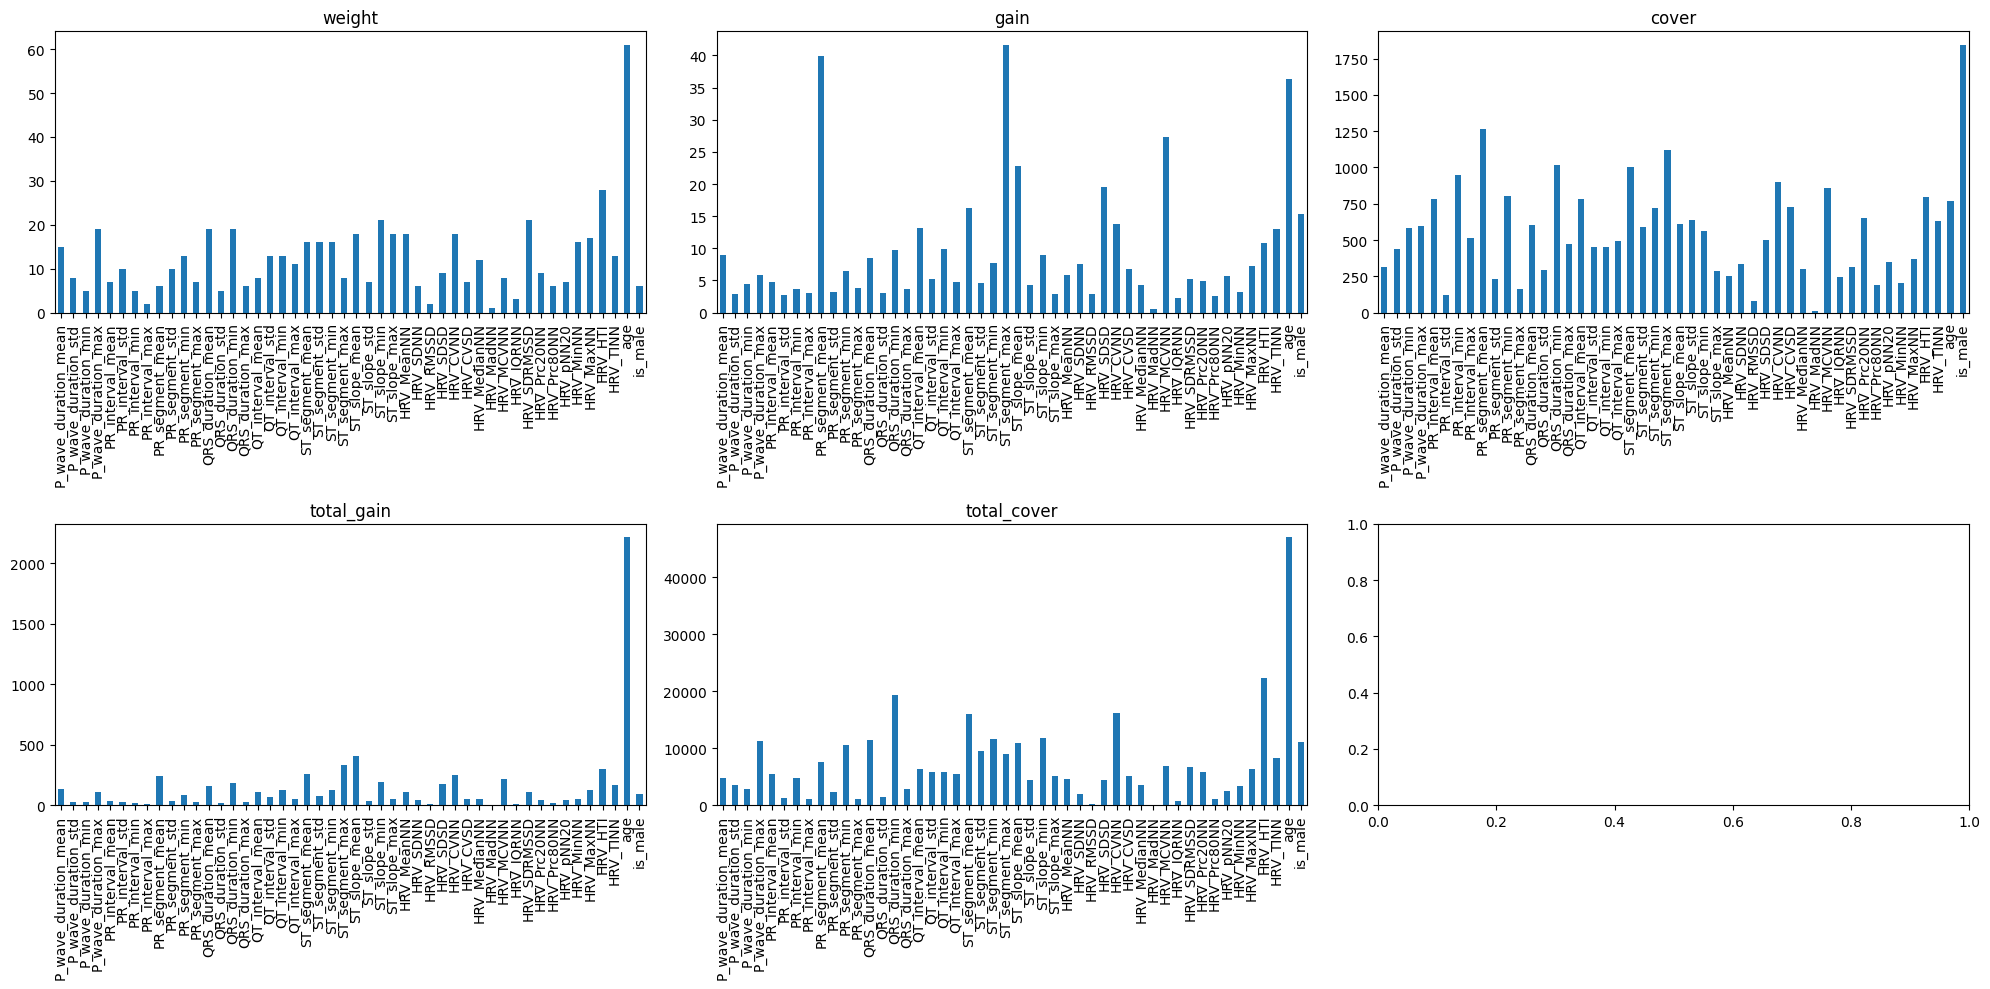

In [144]:
_, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 10))
for ax, imp_type in zip(axes.ravel(), ['weight', 'gain', 'cover', 'total_gain', 'total_cover']):
    pd.Series(xbm.get_booster().get_score(importance_type=imp_type)).plot.bar(ax=ax, title=imp_type)
plt.tight_layout()

# SVC with Optuna

We use the genetic algorithm to optimize the hyperparameters of the SVC.

In [145]:
def objective(trial):
    svc_c = trial.suggest_float('svc_c', 1e-1, 1e4, log=True)
    svc_gamma = trial.suggest_float('svc_gamma', 0.0001, 1, log=True)
    classifier_obj = SVC(C=svc_c, gamma=svc_gamma, kernel='rbf', probability=False, random_state=SEED)
    classifier_obj.fit(X_train, y_train)
    roc_auc = roc_auc_score(y_test, classifier_obj.predict(X_test))
    return roc_auc 

In [146]:
study = optuna.create_study(direction='maximize', study_name='SVC')
study.optimize(objective, n_trials=20)

[I 2025-02-09 16:58:55,083] A new study created in memory with name: SVC
[I 2025-02-09 16:59:29,577] Trial 0 finished with value: 0.6614154419065374 and parameters: {'svc_c': 33.255662508280615, 'svc_gamma': 0.1352545876388224}. Best is trial 0 with value: 0.6614154419065374.
[I 2025-02-09 17:00:03,443] Trial 1 finished with value: 0.6488159483977077 and parameters: {'svc_c': 1231.387821148107, 'svc_gamma': 0.09815118925351618}. Best is trial 0 with value: 0.6614154419065374.
[I 2025-02-09 17:00:32,799] Trial 2 finished with value: 0.6595073392159199 and parameters: {'svc_c': 111.0035806269019, 'svc_gamma': 0.12439479726334843}. Best is trial 0 with value: 0.6614154419065374.
[I 2025-02-09 17:00:42,779] Trial 3 finished with value: 0.7061571500994059 and parameters: {'svc_c': 73.98277004021122, 'svc_gamma': 0.0014914311638390954}. Best is trial 3 with value: 0.7061571500994059.
[I 2025-02-09 17:00:58,327] Trial 4 finished with value: 0.6862876510070249 and parameters: {'svc_c': 73.2770

We select the RBF kernel for the SVC, as it is the most common kernel for the SVC and is suitable for non-linearly separable data.

The two hyperparameters are the `C` parameter and the `gamma` parameter. 

`C` is the regularization parameter, which can be seen as the cost of misclassification. A large `C` penalizes misclassifications heavily, while a small `C` tolerates some misclassifications for simplicity. Thus, a large `C` can lead to overfitting, while a small `C` can lead to underfitting.

`gamma` is the kernel coefficient for the RBF kernel. A large `gamma` makes the decision boundary more complex, while a small `gamma` makes the decision boundary simpler. Thus, a large `gamma` can lead to overfitting, while a small `gamma` can lead to underfitting.

We now define a default range for the hyperparameters and the genetic algorithm.

In order to have a good genetic pool, we set a substantial population size of 50 individuals, running for 10 generation and with a mutation probability of 0.3, which is quite high, but necessary to avoid local minima.

We now define the seeds for reproducibility and then run the genetic algorithm.

In [147]:
print(f"Optimized C: {study.best_params['svc_c']}, Optimized gamma: {study.best_params['svc_gamma']}")

Optimized C: 73.98277004021122, Optimized gamma: 0.0014914311638390954


Now that we have the best hyperparameters, we can train the SVC with the best hyperparameters and evaluate the model setting the probability to True. 
In this way, we can get the probabilities of the predictions and use them to plot the ROC curve. The results should be better than the ones we get before, since we were not taking into account the probability of the predictions. 
However, the computational time is higher (thus we did not use this approach when looking for the best hyperparameters with the genetic algorithm).

In [148]:
svc = SVC(C=study.best_params['svc_c'], gamma=study.best_params['svc_gamma'], kernel='rbf', probability=True, random_state=SEED)
svc.fit(X_train, y_train)

SVC(C=73.98277004021122, gamma=0.0014914311638390954, probability=True,
    random_state=42)

In [149]:
y_pred = svc.predict(X_test)
y_pred_proba = svc.predict_proba(X_test)[:, 1]

As expected, the results are actually quite good. Now we can plot the confusion matrix and the classification report.

Accuracy: 0.7062
ROC-AUC: 0.7660
F1-score: 0.7023
F-beta score 0.7080405932864949


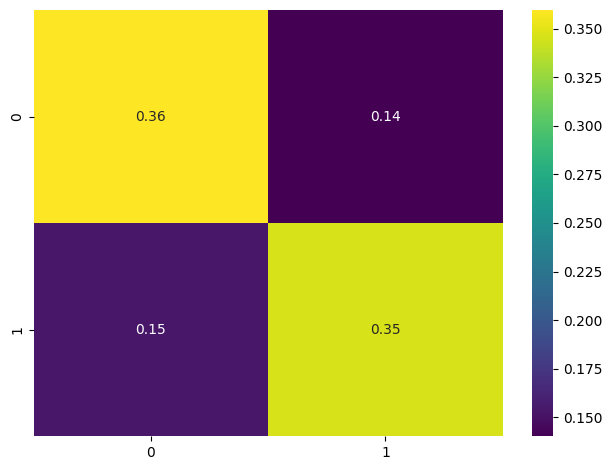

In [150]:
results_dict['SVC'] = print_results(svc, y_test, y_pred, y_pred_proba)

# KNN

Another model that we can try is the KNN. Since the only hyperparameter is the number of neighbors, we can use binary search to find the best number of neighbors.

In [151]:
best_model, best_score = None, 0
cache = {}
l, r = 2, 200

while l <= r:
    mid = (l + r) // 2

    if mid not in cache:
        mid = (l + r) // 2
        mid_model = KNeighborsClassifier(n_neighbors=mid)
        mid_model.fit(X_train, y_train)
        y_pred = mid_model.predict_proba(X_test)[:, 1]
        mid_score = roc_auc_score(y_test, y_pred)
        cache[mid] = mid_score

    if mid-1 not in cache:
        left_model = KNeighborsClassifier(n_neighbors=mid-1)
        left_model.fit(X_train, y_train)
        y_pred = left_model.predict_proba(X_test)[:, 1]
        left_score = roc_auc_score(y_test, y_pred)
        cache[mid-1] = left_score

    if mid_score > best_score:
        best_model, best_score = mid_model, mid_score

    if left_score > mid_score:
        r = mid-1
    else:
        l = mid+1

knn_score_test = best_score
print(f'Best number of neighbors: {best_model.n_neighbors}')

Best number of neighbors: 101


The KNN model has the best results so far. Let's look at the confusion matrix and the classification report.

The confusion matrix is very similar to the ones we get with the other models, but with slighlty worse results than the SVC and the XGBoost.

Accuracy: 0.6783
ROC-AUC: 0.7409
F1-score: 0.6546
F-beta score 0.6849785407725322


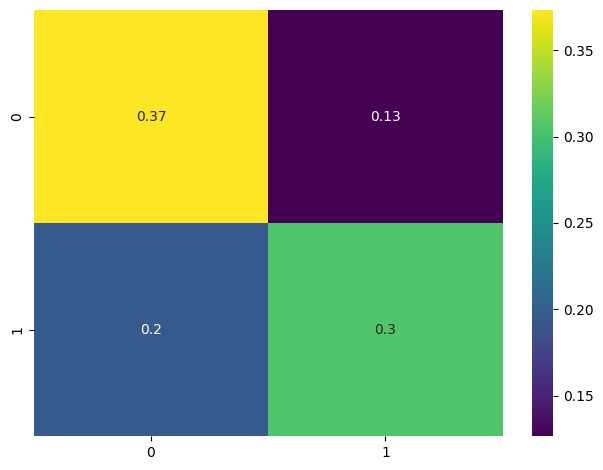

In [152]:
results_dict['KNN'] = print_results(best_model, y_test, best_model.predict(X_test), best_model.predict_proba(X_test)[:, 1])

# Permutation Importance

In [ ]:
r_train = permutation_importance(xbm, X_train, y_train, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_train.importances_mean)

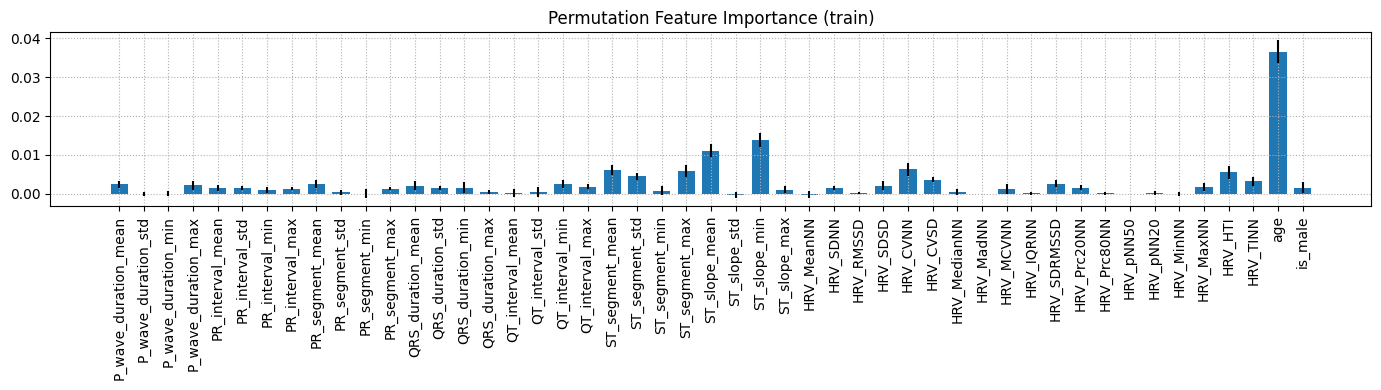

In [191]:
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_train.importances_std, title='Permutation Feature Importance (train)', rotation=90)

In [189]:
r_test = permutation_importance(xbm, X_test, y_test, n_repeats=30, random_state=SEED)
xbm_p_imp = pd.Series(index=X.columns, data=r_test.importances_mean)

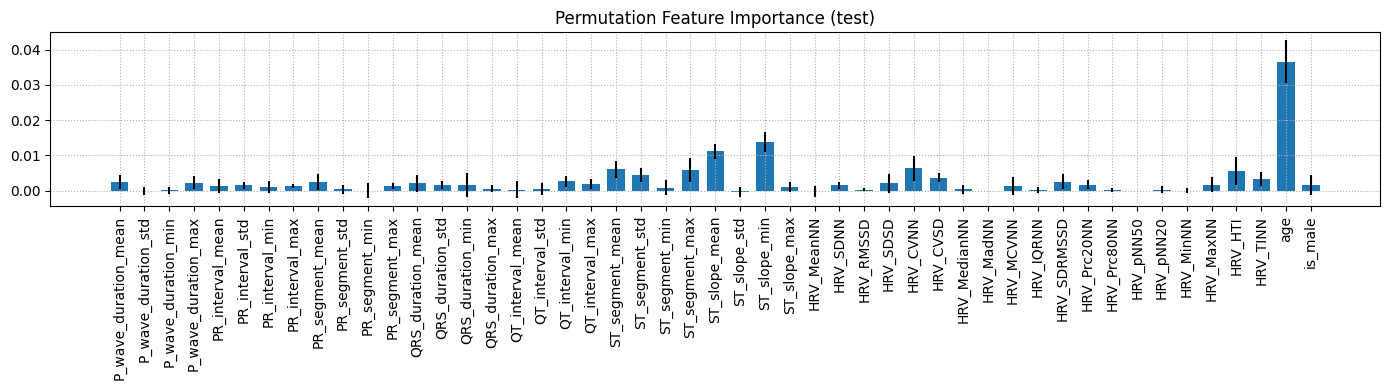

In [192]:
util.plot_bars(xbm_p_imp, figsize=figsize, std=r_test.importances_std, title='Permutation Feature Importance (test)', rotation=90)

# SHAP Values

We can use the SHAP values to explain the predictions of the XGBoost model, as it has very good results.

In [197]:
f = lambda x: xbm.predict_proba(x)[:,1]
explainer = shap.KernelExplainer(f, shap.sample(X_train, 100), link='logit', seed=SEED)

In [198]:
shap_values = explainer(X_test)

100%|██████████| 2617/2617 [1:00:33<00:00,  1.39s/it]


Summary plot.

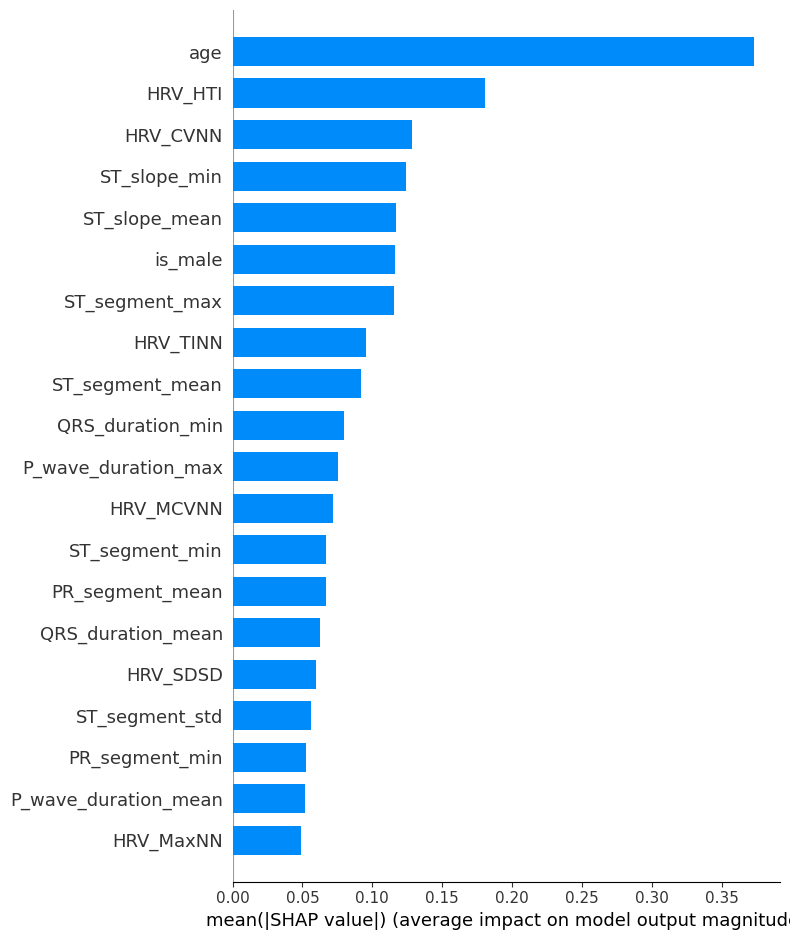

In [254]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=20)

Waterfall plot for the SHAP values for a negative sample.

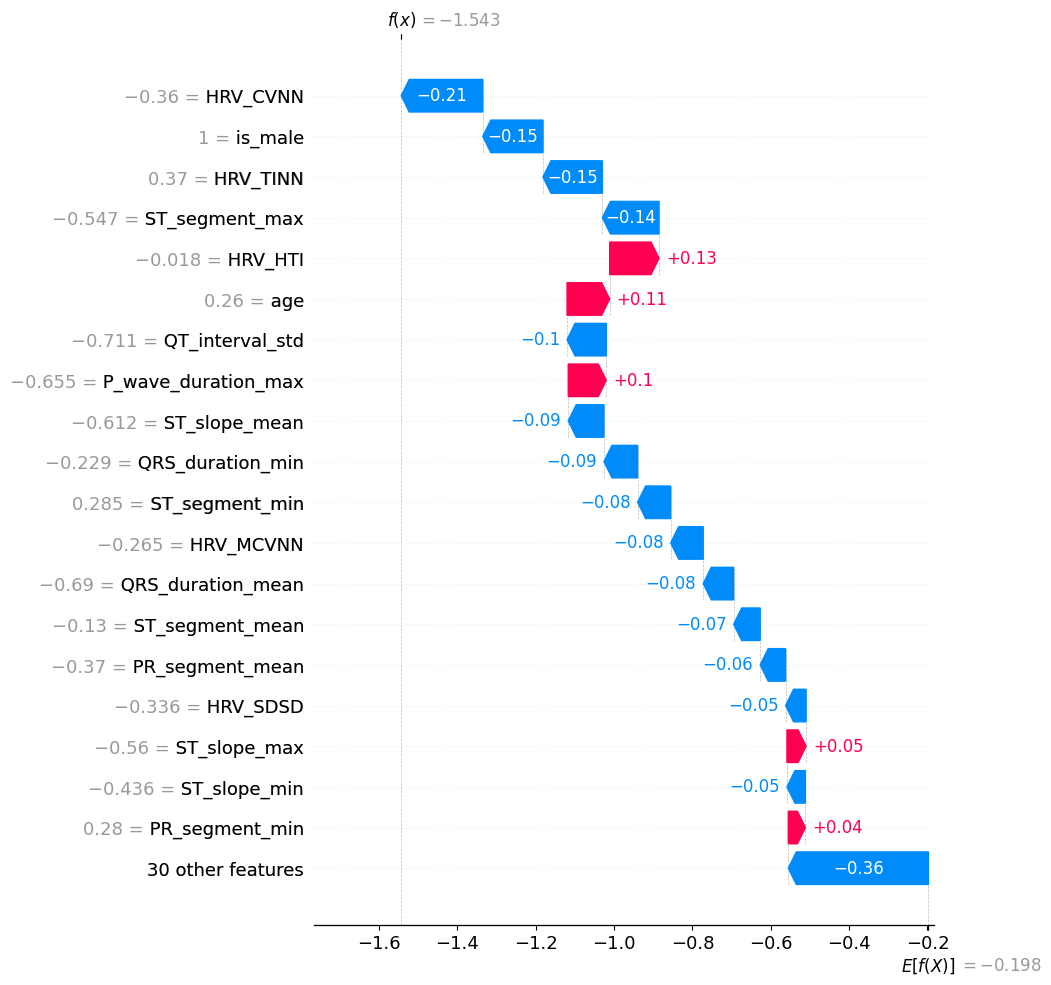

In [256]:
shap.waterfall_plot(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X_test.iloc[0], feature_names=X.columns.tolist()), max_display=20)

Waterfall plot for the SHAP values for a positive sample.

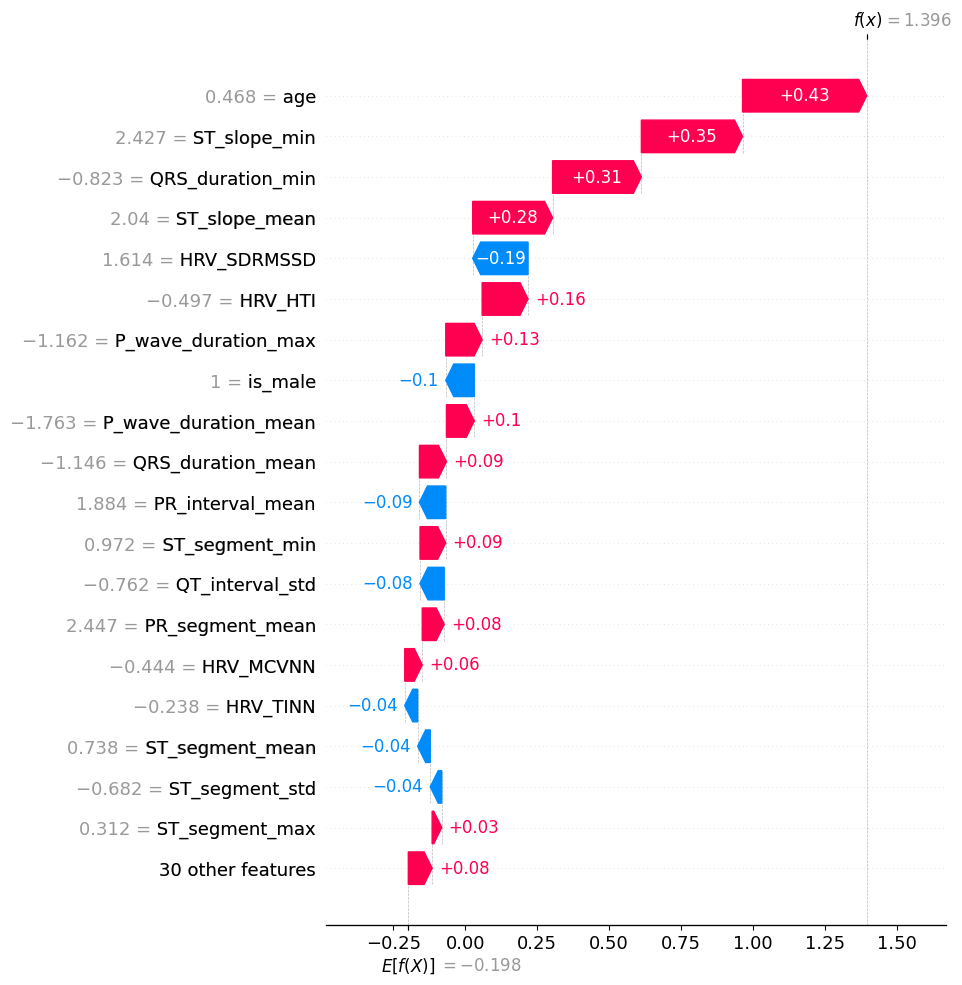

In [257]:
shap.waterfall_plot(shap.Explanation(values=shap_values[1], base_values=explainer.expected_value, data=X_test.iloc[1], feature_names=X.columns.tolist()), max_display=20)

Now we print the beeswarm plot for the SHAP values.

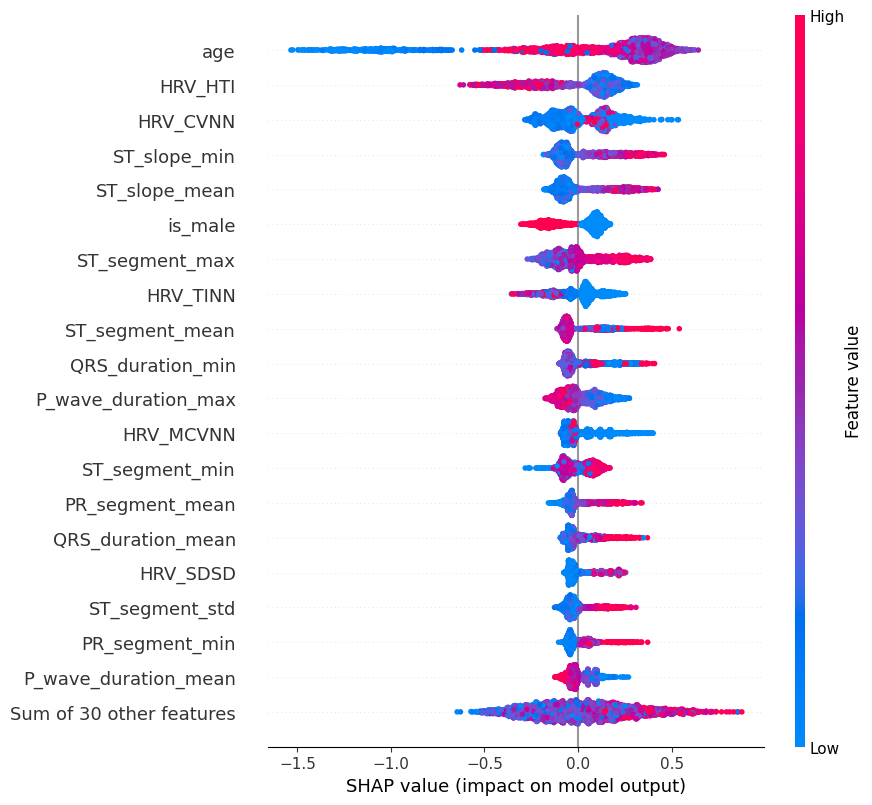

In [258]:
shap.plots.beeswarm(shap_values, max_display=20)

We take the mean of the absolute SHAP values for each feature and select the top 20 features.

In [259]:
shap_mean = np.abs(shap_values.values).mean(axis=0)
shap_mean = pd.Series(index=X.columns, data=shap_mean)
shap_mean.sort_values(ascending=False, inplace=True)
best_20_shap = shap_mean.head(20)

Now we can run again the XGBoost model with the top 20 features and see the results.

In [270]:
X_train_fs = X_train[best_20_shap.index]
X_test_fs = X_test[best_20_shap.index]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_fs = GridSearchCV(base_est, param_grid=param_grid)
gscv_fs.fit(X_train_fs, y_train)
xbm_fs, xbm_params_fs = gscv_fs.best_estimator_, gscv_fs.best_params_
y_pred = xbm_fs.predict_proba(X_test_fs)[:, 1]
xbm_score_test_fs = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_fs["max_depth"]}, n_estimators={xbm_params_fs["n_estimators"]}, reg_lambda={xbm_params_fs["reg_lambda"]:.2f}: {xbm_score_test_fs:.4f} (test)')

AUC score for max_depth=4, n_estimators=40, reg_lambda=100.00: 0.7804 (test)


Now we can plot the confusion matrix and the classification report.

Accuracy: 0.7023
ROC-AUC: 0.7804
F1-score: 0.7103
F-beta score 0.6992238980817104


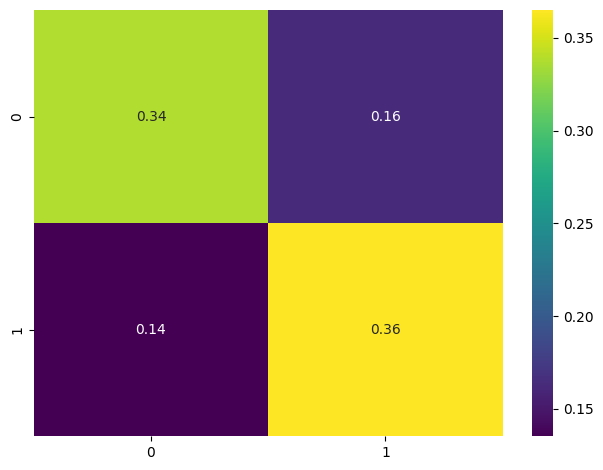

In [271]:
results_dict['XGBoost-SHAP'] = print_results(xbm_fs, y_test, xbm_fs.predict(X_test_fs), xbm_fs.predict_proba(X_test_fs)[:, 1])

---

# BorutaPy Feature Selection

In [275]:
bfs = BorutaPy(xbm, n_estimators='auto', max_iter=100, verbose=0, random_state=SEED, early_stopping=True)
bfs.fit(X=X, y=y)

BorutaPy(early_stopping=True,
         estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=None, device=None,
                                 early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric=None,
                                 feature_types=None, gamma=None,
                                 grow_policy=None, importance_type='total_gain',
                                 interaction_constraints=None,
                                 learning_rate=None, max_bin=None,
                                 max_cat_threshold=None, max_cat_to_onehot=None,
                                 max_delta_step=None, max_depth=4,
                                 max_leaves=None, min_child_weight=None,
                                 missing=nan, monotone_constraints=None,
                                 multi_strategy=None, n_estimators=173,
                                 n_jobs=None, num_parallel_tree=None,
                                 random_state=900708429, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7CB9D13DA540)

In [276]:
print('Confirmed important:', X.columns[bfs.ranking_ == 1].values)
print('Uncomfirmed:', X.columns[bfs.ranking_ == 2].values)
print('Confirmed unimportant:', X.columns[bfs.ranking_ > 2].values)

Confirmed important: ['P_wave_duration_mean' 'PR_segment_mean' 'QRS_duration_mean'
 'QRS_duration_min' 'QT_interval_min' 'QT_interval_max' 'ST_segment_mean'
 'ST_segment_std' 'ST_segment_min' 'ST_segment_max' 'ST_slope_mean'
 'ST_slope_min' 'HRV_MeanNN' 'HRV_SDSD' 'HRV_CVNN' 'HRV_CVSD' 'HRV_MCVNN'
 'HRV_SDRMSSD' 'HRV_Prc20NN' 'HRV_HTI' 'HRV_TINN' 'age']
Uncomfirmed: ['QT_interval_mean' 'ST_slope_max']
Confirmed unimportant: ['P_wave_duration_std' 'P_wave_duration_min' 'P_wave_duration_max'
 'PR_interval_mean' 'PR_interval_std' 'PR_interval_min' 'PR_interval_max'
 'PR_segment_std' 'PR_segment_min' 'PR_segment_max' 'QRS_duration_std'
 'QRS_duration_max' 'QT_interval_std' 'ST_slope_std' 'HRV_SDNN'
 'HRV_RMSSD' 'HRV_MedianNN' 'HRV_MadNN' 'HRV_IQRNN' 'HRV_Prc80NN'
 'HRV_pNN50' 'HRV_pNN20' 'HRV_MinNN' 'HRV_MaxNN' 'is_male']


In [281]:
pd.DataFrame(data=bfs.ranking_, index=X.columns).rename(columns={0: 'Ranking'}).sort_values(by='Ranking', ascending=True)

,Ranking
P_wave_duration_mean,1
ST_segment_mean,1
ST_segment_std,1
ST_segment_min,1
ST_segment_max,1
age,1
ST_slope_min,1
HRV_MeanNN,1
HRV_SDSD,1
HRV_CVNN,1


In [293]:
X_train_boruta = X_train[X.columns[bfs.ranking_ == 1].values]
X_test_boruta = X_test[X.columns[bfs.ranking_ == 1].values]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_boruta = GridSearchCV(base_est, param_grid=param_grid)
gscv_boruta.fit(X_train_boruta, y_train)
xbm_boruta, xbm_params_boruta = gscv_boruta.best_estimator_, gscv_boruta.best_params_
y_pred = xbm_boruta.predict_proba(X_test_boruta)[:, 1]
xbm_score_test_boruta = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_boruta["max_depth"]}, n_estimators={xbm_params_boruta["n_estimators"]}, reg_lambda={xbm_params_boruta["reg_lambda"]:.2f}: {xbm_score_test_boruta:.4f} (test)')

AUC score for max_depth=4, n_estimators=35, reg_lambda=100.00: 0.7800 (test)


Accuracy: 0.7081
ROC-AUC: 0.7800
F1-score: 0.7160
F-beta score 0.70466852041563


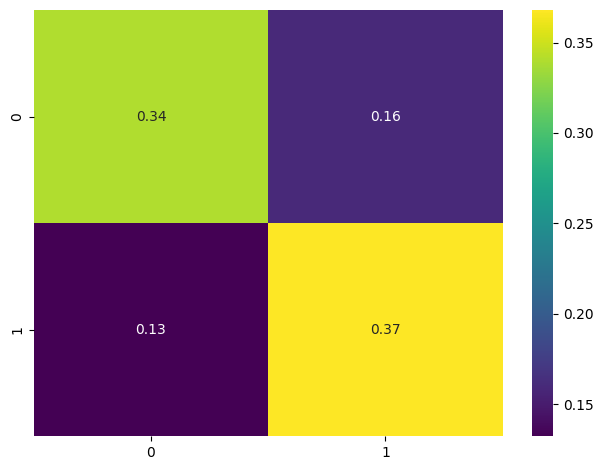

In [294]:
results_dict['XGBoost-Boruta'] = print_results(xbm_boruta, y_test, xbm_boruta.predict(X_test_boruta), xbm_boruta.predict_proba(X_test_boruta)[:, 1])

In [297]:
shap_20_feature_set = set(best_20_shap.index)
boruta_feature_set = set(X.columns[bfs.ranking_ == 1].values)
intersection = shap_20_feature_set.intersection(boruta_feature_set)

X_train_intersection = X_train[list(intersection)]
X_test_intersection = X_test[list(intersection)]

base_est = xgboost.XGBClassifier(tree_method='hist', importance_type='total_gain')
param_grid={'max_depth': [2, 3, 4], 'n_estimators': list(range(20, 41, 5)), 'reg_lambda': np.linspace(0, 500, 6)}
gscv_intersection = GridSearchCV(base_est, param_grid=param_grid)
gscv_intersection.fit(X_train_intersection, y_train)
xbm_intersection, xbm_params_intersection = gscv_intersection.best_estimator_, gscv_intersection.best_params_
y_pred = xbm_intersection.predict_proba(X_test_intersection)[:, 1]
xbm_score_test_intersection = roc_auc_score(y_test, y_pred)

print(f'AUC score for max_depth={xbm_params_intersection["max_depth"]}, n_estimators={xbm_params_intersection["n_estimators"]}, reg_lambda={xbm_params_intersection["reg_lambda"]:.2f}: {xbm_score_test_intersection:.4f} (test)')

AUC score for max_depth=3, n_estimators=40, reg_lambda=100.00: 0.7741 (test)


Accuracy: 0.6943
ROC-AUC: 0.7741
F1-score: 0.7024
F-beta score 0.6915750915750916


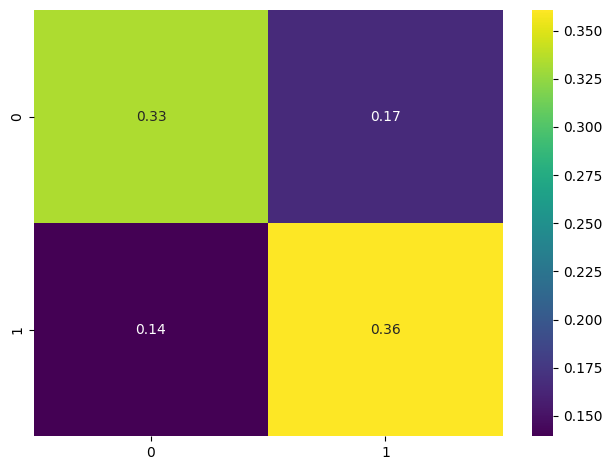

In [298]:
results_dict['XGBoost-Intersection'] = print_results(xbm_intersection, y_test, xbm_intersection.predict(X_test_intersection), xbm_intersection.predict_proba(X_test_intersection)[:, 1])

In [314]:
from statsmodels.stats.contingency_tables import mcnemar

def compute_p_value(pipeline1_preds : pd.Series, pipeline2_preds : pd.Series, true_labels: pd.Series):
    """
    Compute the p-value for statistical significance of improvement between two binary classification pipelines.

    Parameters:
        pipeline1_preds (pd.Series): Predictions from pipeline 1 (binary values: 0 or 1).
        pipeline2_preds (pd.Series): Predictions from pipeline 2 (binary values: 0 or 1).
        true_labels (pd.Series): Ground truth labels (binary values: 0 or 1).

    Returns:
        float: The p-value for the McNemar's test.
    """
    # Convert inputs to numpy arrays
    pipeline1_preds = np.array(pipeline1_preds)
    pipeline2_preds = np.array(pipeline2_preds)
    true_labels = np.array(true_labels)

    # Create the contingency table
    both_correct = np.sum((pipeline1_preds == true_labels) & (pipeline2_preds == true_labels))
    only_pipeline1_correct = np.sum((pipeline1_preds == true_labels) & (pipeline2_preds != true_labels))
    only_pipeline2_correct = np.sum((pipeline1_preds != true_labels) & (pipeline2_preds == true_labels))
    both_incorrect = np.sum((pipeline1_preds != true_labels) & (pipeline2_preds != true_labels))

    contingency_table = np.array([[both_correct, only_pipeline2_correct],
                                   [only_pipeline1_correct, both_incorrect]])

    # Perform McNemar's test
    result = mcnemar(contingency_table, exact=True)

    return result.pvalue

def compare_models(model_prediction1, model_prediction1_name, model_prediction2, model_prediction2_name, original_labels):
    significance_level = 0.05 # or 0.01 for even more significance probability level
    p_value = compute_p_value(model_prediction1, model_prediction2, original_labels)

    if p_value < significance_level:
        print(f"{model_prediction1_name} and {model_prediction2_name} results ARE significantly different (p-value = {p_value:.4f}).")
    else:
        print(f"{model_prediction1_name} and {model_prediction2_name} results are NOT significantly different (p-value = {p_value:.4f}).")

In [317]:
compare_models(xbm_fs.predict(X_test_fs), 'XGBoost-SHAP', xbm_boruta.predict(X_test_boruta), 'XGBoost-Boruta', y_test)
compare_models(xbm_fs.predict(X_test_fs), 'XGBoost-SHAP', xbm_intersection.predict(X_test_intersection), 'XGBoost-Intersection', y_test)
compare_models(xbm_boruta.predict(X_test_boruta), 'XGBoost-Boruta', xbm_intersection.predict(X_test_intersection), 'XGBoost-Intersection', y_test)

XGBoost-SHAP and XGBoost-Boruta results are NOT significantly different (p-value = 0.3652).
XGBoost-SHAP and XGBoost-Intersection results are NOT significantly different (p-value = 0.1784).
XGBoost-Boruta and XGBoost-Intersection results ARE significantly different (p-value = 0.0219).


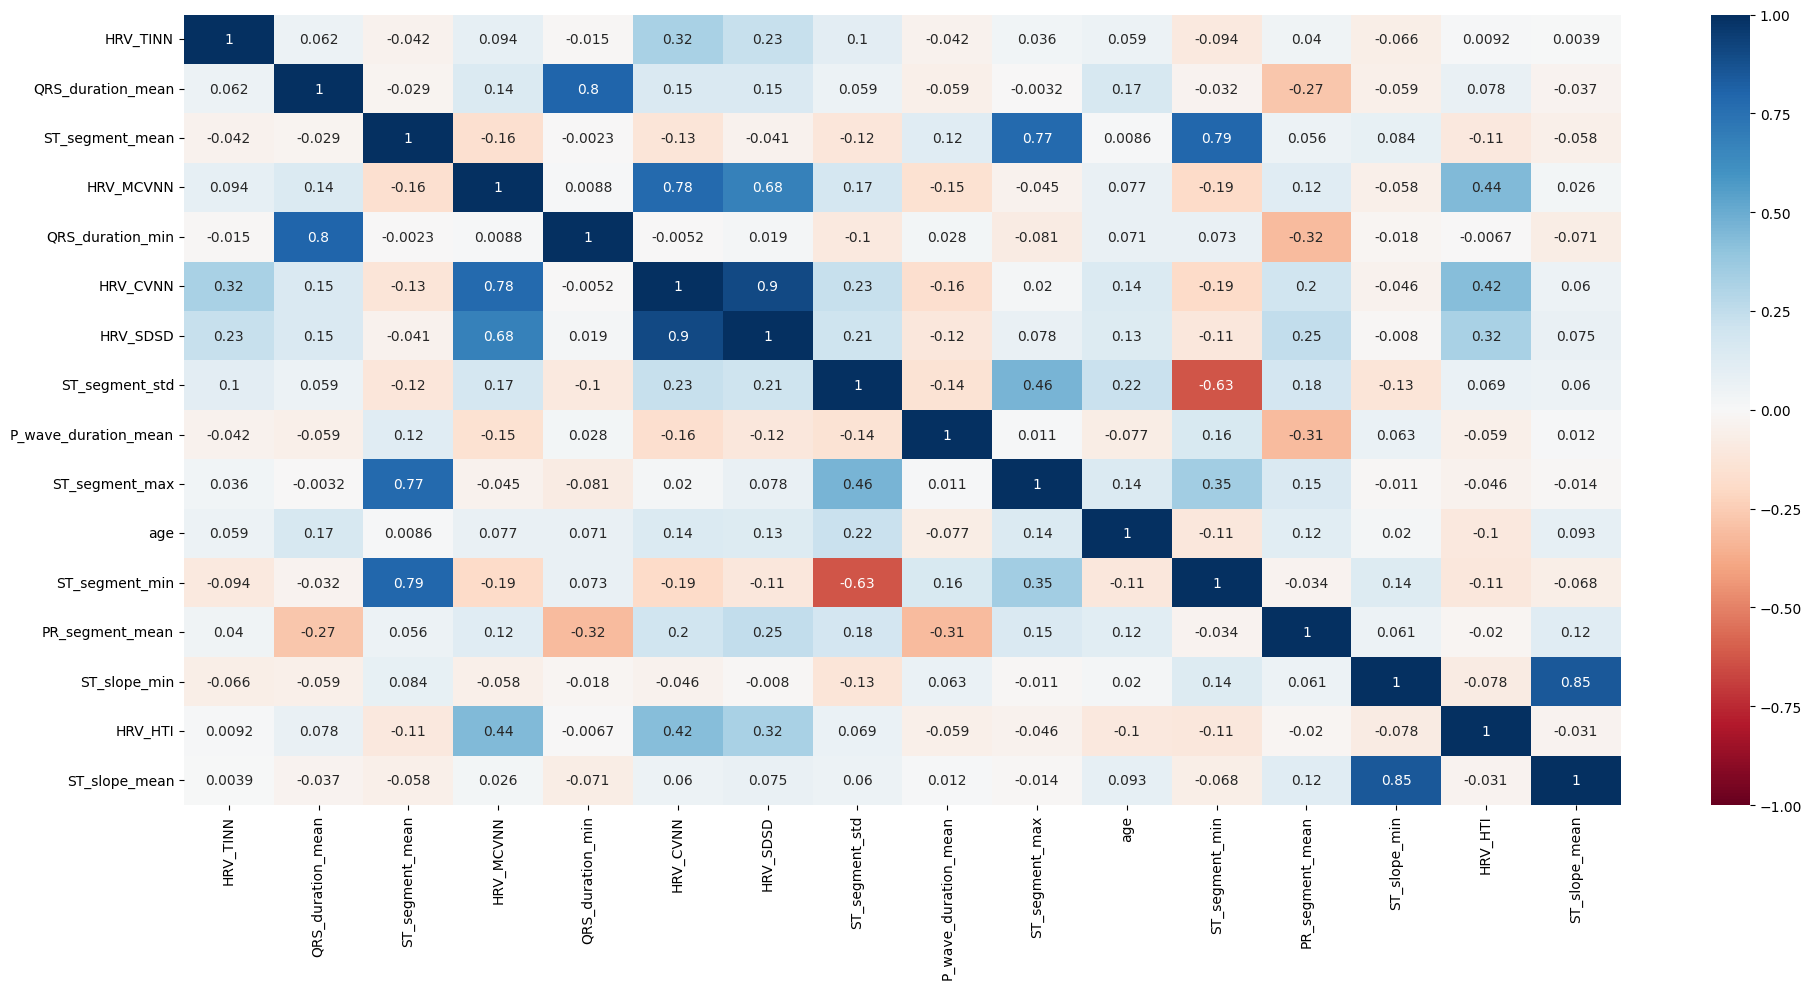

In [331]:
plt.figure(figsize=(20,10))
sn.heatmap(df[list(intersection)].corr(method='pearson'), annot=True, vmin=-1, vmax=1, cmap='RdBu')
plt.tight_layout()

In [333]:
pd.DataFrame(results_dict)

,Logistic Regression,XGBoost,SVC,KNN,XGBoost-SHAP,XGBoost-Boruta,XGBoost-Intersection
acc,0.681697,0.705006,0.706152,0.678258,0.702331,0.708063,0.694306
auc,0.745726,0.781293,0.766039,0.740854,0.780380,0.780037,0.774087
f1,0.671141,0.714497,0.702284,0.654635,0.710301,0.715985,0.702381
f_beta,0.684932,0.701118,0.708041,0.684979,0.699224,0.704669,0.691575


---

# Deep Learning

## Why?

Another approach that we can try is to use **Deep Learning** with the aim of improving the results in terms of ROC AUC.

In this context, we can use any kind of deep learning model, such as a simple **feedforward neural network**, a **convolutional neural network**, or a **recurrent neural network**.

However, Fully Connected Neural Networks are not suitable for time series data, as they do not take into account the **temporal dependencies** in the data. Moreover, we do not have only one-dimensional data, but **12 leads** of ECG signals for each record and **demographic information**.

Thus, we can use a Convolutional Neural Network (CNN) to take into account the **spatial dependencies** in the data, as the ECG signals are two-dimensional data. In particular, we can use a **1D CNN** for each lead of the ECG signals and a Fully Connected Neural Network for the demographic information.

We can also use a Recurrent Neural Network (RNN) to take into account the temporal dependencies in the data, as the ECG signals are time series data. This RNN could be put on top of the CNN to take into account both the spatial and temporal dependencies in the data. This approach is the SOTA for a variety of tasks like **Sleep Stage Classification**, **ECG Classification**, etc.

Although these models are more complex than the previous ones, they can provide better results in terms of ROC AUC.

## Explainability?

Deep Learning models are often considered as black boxes, as they are very complex and it is difficult to understand how they make predictions. However, there are some techniques that can help us understand how the model makes predictions, such as SHAP values, LIME, and Grad-CAM. In particular, SHAP values can help us understand the importance of each feature in the model's predictions.

We will try to leverage the Deep Explainer of the SHAP library to explain the predictions of the Deep Learning model.

More sophisticated techniques like LIME and Grad-CAM can also be used to explain the predictions of the Deep Learning model. Grad-CAM can help us understand which parts of the ECG signals are important for the model's predictions as to highlight which leads are more important in the model's predictions. We hypothesize that the lead II is the most important one, as it is the most commonly used lead in ECG analysis but we will see if this is true by using Grad-CAM.

In [334]:
df = pd.read_csv('data/signals_features.csv')
df = df.fillna(value=0)
scaler = StandardScaler()
scaler.set_output(transform='pandas')
df.iloc[:, 1:-3] = scaler.fit_transform(df.iloc[:, 1:-3])

In [335]:
def clean_signal(ecg_channel, sampling_rate: int = 400):
    """
    Clean a single ECG channel.
    """
    detrend = nk.signal_detrend(ecg_channel, method='polynomial', order='auto', sampling_rate=sampling_rate)
    cleaned = nk.signal_filter(detrend, sampling_rate=sampling_rate, lowcut=2, highcut=9, method='butterworth')
    return cleaned

The `get_features_and_labels` function takes each of the record inside the data folder and extracts the features and labels from the record. The features are the ECG signals and the demographic information, while the labels are the target variable. To speedup the process, we can use the `joblib` library to parallelize the process and extract the features and labels from each record in parallel (as they are independent from each other).

In [336]:
def get_features_and_labels(records_id: str, data_folder: Path, clean: bool = False):
    record_path = (data_folder / records_id).absolute().__str__()
    header = load_header(record_path)
    signals, fields = load_signals(record_path)
    if clean:
        signals = np.stack(Parallel(n_jobs=-1)(delayed(clean_signal)(signals[:, channel], sampling_rate=400) for channel in range(signals.shape[1])))
    label = get_label(header)
    age = get_age(header)
    sex = get_sex(header)
    handcrafted = df[df['exam_id'] == int(records_id)].iloc[:, 1:-3].values
    return signals, label, age, sex, handcrafted

The we can create the `ECGDataset` class to load the features and labels so that we can use them to train the deep learning model by leveraging PyTorch datasets and dataloaders.

While creating the `ECGDataset` class, we can also apply some transformations to the features and labels, such as converting them to PyTorch tensors and normalizing the features.

In this context, the age values are normalized in the range [0, 1] while the signals are standardized by subtracting the mean and dividing by the standard deviation.

In some instances, the signals were shorter than the maximum length of 4096, so we padded them with zeros to have the same length for each signal.

At the end, the dataset is split into training and testing sets, and the dataloaders are created to load the data in batches.

In [337]:
class ECGDataset(Dataset):
    def __init__(self, features, labels):
        signals, ages, sexes, handcrafted = zip(*features)
        ages = np.array(ages)
        self.features = signals
        self.ages = (ages - ages.min()) / (ages.max() - ages.min())
        self.sexes = sexes
        self.labels = labels
        self.handcrafted = handcrafted
        self.min_len = min(signal.shape[0] for signal in signals)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        signals = torch.tensor(self.features[idx], dtype=torch.float32)
        ages = torch.tensor(self.ages[idx], dtype=torch.float32)
        sexes = torch.tensor(self.sexes[idx], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        handcrafted = torch.tensor(self.handcrafted[idx], dtype=torch.float32)

        # Standardize the signals
        signals = (signals - signals.mean()) / signals.std()

        # Truncate the signals to half the maximum length
        signals = signals[:self.min_len :]

        signals = signals.transpose(0, 1)
        label = label.unsqueeze(0)
        
        #handcrafted = (handcrafted - handcrafted.min()) / (handcrafted.max() - handcrafted.min() + 1e-8)

        return signals, label, ages, sexes, handcrafted.squeeze(0)

Get the feature and labels for each record in parallel

In [338]:
data = Parallel(n_jobs=-1)(delayed(get_features_and_labels)(record_id, train_data_folder) for record_id in tqdm(train_records, desc='Loading signals'))

Loading signals: 100%|██████████| 13092/13092 [00:46<00:00, 280.08it/s]


Map the data to the features and labels

In [339]:
features, labels, ages, sexes, handcrafted = zip(*data)
features = [f for f in features]

In [340]:
ages = np.array(ages, dtype=np.float32)

In [341]:
sexes = np.array([1 if sex.lower() == 'male' else 0 for sex in sexes], dtype=np.float32)

Combine the features and labels into a dataset and split it into training and testing sets

In [342]:
# Combine features with demographic data
X = [(f, age, sex, handcrafted) for f, age, sex, handcrafted in zip(features, ages, sexes, handcrafted)]
y = np.array(labels)

In [343]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.10, random_state=SEED, stratify=y_train)

print("Train", len(X_train))
print("Val", len(X_val))
print("Test", len(X_test))

Train 9425
Val 1048
Test 2619


In [344]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([4709, 4716]))
(array([0, 1]), array([524, 524]))
(array([0, 1]), array([1309, 1310]))


Define the dataloaders to load the data in batches

In [345]:
BATCH_SIZE = 128

train_dataset = ECGDataset(X_train, y_train)
val_dataset = ECGDataset(X_val, y_val)
test_dataset = ECGDataset(X_test, y_test)
train_dloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_dloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [346]:
train_dloader.dataset[0][0].shape

torch.Size([12, 1634])

## Model

The model we are going to use is a 1D Conv SE-ResNet18, which is a convolutional neural network with squeeze-and-excitation blocks and a ResNet18 architecture. The ResNet18 architecture is a convolutional neural network with residual connections that is widely used for image classification tasks. The squeeze-and-excitation blocks are used to model the dependencies between the channels of the input data, which can be useful for ECG signals, as they have multiple leads that are related to each other. In this way, the model can learn the spatial dependencies in the data and improve the performance of the model by focusing on the most important leads.

In order to integrate the demographic information into the model, we can use a Fully Connected Neural Network that takes the demographic information as input and outputs a vector of the same size as the output of the convolutional neural network. This vector can be concatenated with the output of the convolutional neural network and passed through a linear layer to get the final output of the model.

More sophisticated techniques can be used to integrate the demographic information into the model, such as attention mechanisms, by weighting the output of the convolutional neural network based on the demographic information. Alternatives might esplore the Feature-wise Linear Modulation (FiLM) layers by conditioning the convolutional neural network on the demographic information. This intuition comes from the fact that the demographic information can be used to modulate the features extracted by the convolutional neural network, so that the model can learn that specific patterns might also be related to the demographic information. This is particularly useful when the demographic information is related to the target variable, as it can help the model to learn the relationship between the demographic information and the target variable. As we have seen in the EDA, the demographic information is related to the target variable, so it can be useful to integrate it into the model by using a concatenation or a modulation approach.

>**Note**: For our purpose the concatenation approach is enough, but the other approaches can be explored in future work to improve the performance of the model on a greater scale of training data.

In [347]:
class SELayer(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SELayer, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.LeakyReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)



def conv3x1(in_planes, out_planes, stride=1):
    """3x3 convolution with padding"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=7, stride=stride,
                     padding=3, bias=False)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv1d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = conv3x1(inplanes, planes, stride)
        self.bn1 = nn.BatchNorm1d(planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.conv2 = conv3x1(planes, planes)
        self.bn2 = nn.BatchNorm1d(planes)
        self.se = SELayer(planes)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = conv1x1(inplanes, planes)
        self.bn1 = nn.BatchNorm1d(planes)
        self.conv2 = conv3x1(planes, planes, stride)
        self.bn2 = nn.BatchNorm1d(planes)
        self.conv3 = conv1x1(planes, planes * self.expansion)
        self.bn3 = nn.BatchNorm1d(planes * self.expansion)
        self.se = SELayer(self.expansion * planes)
        self.relu = nn.LeakyReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride
        self.dropout = nn.Dropout(.2)

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv3(out)
        out = self.bn3(out)
        out = self.se(out)
        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, in_channel=12, out_channel=1, zero_init_residual=False):
        super(ResNet, self).__init__()
        self.inplanes = 64
        self.conv1 = nn.Conv1d(in_channel, 64, kernel_size=15, stride=2, padding=7,
                               bias=False)
        self.bn1 = nn.BatchNorm1d(64)
        self.relu = nn.LeakyReLU(inplace=True)
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        
        self.gradients = {}
        self.activations = {}
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        # Demographic data processing
        self.demographic_fc = nn.Sequential(
            nn.Linear(2, 256),  # 2 demographic features: age and sex
            nn.LeakyReLU(),
            nn.Linear(256, 512 * block.expansion),
            nn.LeakyReLU()
        )
        # Final FC
        self.fc = nn.Linear(512 * block.expansion * 2, out_channel)

        # Hook registration function
        self._register_hooks()

        for m in self.modules():
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                nn.BatchNorm1d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes))

        return nn.Sequential(*layers)

    def _register_hooks(self):
        """
        Register hooks to capture activations and gradients.
        """
        for name, module in self.named_modules():
            if isinstance(module, nn.Conv1d):
                module.register_full_backward_hook(self._forward_hook(name))
                module.register_full_backward_hook(self._backward_hook(name))

    def _forward_hook(self, name):
        def hook(module, input, output):
            self.activations[name] = output
        return hook

    def _backward_hook(self, name):
        def hook(module, grad_input, grad_output):
            self.gradients[name] = grad_output[0]
        return hook
    
    def get_activations_gradient(self, layer_name):
        return self.gradients[layer_name]

    def get_activations(self, layer_name):
        return self.activations[layer_name]

    def forward(self, ecg_features, demo_features, hand_features):
        # Forward pass
        x = self.conv1(ecg_features)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)

        z = self.demographic_fc(demo_features)

        # Concatenate ECG and demographic features
        combined = torch.cat((x, z), dim=1)

        return self.fc(combined)

In [348]:
with torch.no_grad():
    torch.cuda.empty_cache()

if 'model' in locals():
    del model
    print("Model deleted!")

gc.collect()

992448

Parameters of the SE-ResNet18 (the 18 comes from the number of layers in the network, hence the 2, 2, 2, 2 means that there are 2 residual blocks in each of the 4 layers of the network):

In [349]:
resnet_params = {
    'layers': [2, 2, 2, 2],
    "in_channel":12, 
    "out_channel":1, 
    "zero_init_residual":False
}

The model is trained with the AdamW optimizer and the Binary Cross-Entropy with Logits Loss, which is suitable for binary classification tasks. The learning rate is set to 1e-3 with weight decay of 1e-4 to prevent overfitting.

To handle every possible case of unbalanced data, we gave a score to the positive class based on the sum of the labels of the negative class divided by the sum of all the labels. This score is used to weight the loss function and avoid the model to be biased towards the majority class.

In [350]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model
model = ResNet(BasicBlock, **resnet_params)
model.to(device)

# Positive class weight
pos_weight = (y==0.).sum()/y.sum()

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, eta_min=1e-5, T_max=74*15)

# Define epochs and patience
epochs = 30
patience = 10

In [351]:
summary(model, input_size=[(BATCH_SIZE, 12, 1634),(BATCH_SIZE, 2),(BATCH_SIZE, 47)])

Layer (type:depth-idx)                        Output Shape              Param #
ResNet                                        [128, 1]                  --
├─Conv1d: 1-1                                 [128, 64, 817]            11,520
├─BatchNorm1d: 1-2                            [128, 64, 817]            128
├─LeakyReLU: 1-3                              [128, 64, 817]            --
├─MaxPool1d: 1-4                              [128, 64, 409]            --
├─Sequential: 1-5                             [128, 64, 409]            --
│    └─BasicBlock: 2-1                        [128, 64, 409]            --
│    │    └─Conv1d: 3-1                       [128, 64, 409]            28,672
│    │    └─BatchNorm1d: 3-2                  [128, 64, 409]            128
│    │    └─LeakyReLU: 3-3                    [128, 64, 409]            --
│    │    └─Dropout: 3-4                      [128, 64, 409]            --
│    │    └─Conv1d: 3-5                       [128, 64, 409]            28,672
│    │

The model is then trained for 30 epochs with early stopping based on the validation loss to prevent overfitting. The model is saved when the validation loss is minimized. After 10 epochs without improvement, the training is stopped.

The learning rate follows a Cosine Annealing Schedule, which decreases the learning rate from the initial value to a minimum value in a range of epochs. This can help the model to converge faster and avoid local minima by reducing the learning rate as the training progresses.

On each epoch, the training data is shuffled and the model is set to training mode to update the weights based on the loss. The model is then set to evaluation mode to evaluate the performance on the validation data. The performance is evaluated in terms of ROC AUC, which is a suitable metric for binary classification tasks.

The model is then evaluated on the testing data to get the final performance of the model. The performance is again evaluated in terms of ROC AUC while also plotting the confusion matrix for a better understanding of the results.

In [352]:
def train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=False, with_handcrafted=False):
    best_val_loss = float('inf')
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        n_elements = 0
        for X, y, age, sex, handcrafted in tqdm(train_dloader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            if with_demographic:
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
            if with_handcrafted:
                handcrafted = handcrafted.to(device)

            optimizer.zero_grad()
            
            if with_demographic and with_handcrafted:
                outputs = model(X, demographic, handcrafted)
            elif with_demographic and not with_handcrafted:
                outputs = model(X, demographic)
            elif not with_demographic and with_handcrafted:
                outputs = model(X, handcrafted)
            else:
                outputs = model(X)

            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            scheduler.step()
            train_loss += loss.item()
            n_elements += len(X)

        train_loss /= n_elements
        
        model.eval()
        val_loss = 0.0
        preds = []
        probabilities = []
        labels = []
        with torch.no_grad():
            for X, y, age, sex, handcrafted in val_dloader:
                X, y = X.to(device), y.to(device)
                if with_demographic:
                    age, sex = age.to(device), sex.to(device)
                    demographic = torch.stack((age, sex), dim=1)
                if with_handcrafted:
                    handcrafted = handcrafted.to(device)

                optimizer.zero_grad()
                
                if with_demographic and with_handcrafted:
                    outputs = model(X, demographic, handcrafted)
                elif with_demographic and not with_handcrafted:
                    outputs = model(X, demographic)
                elif not with_demographic and with_handcrafted:
                    outputs = model(X, handcrafted)
                else:
                    outputs = model(X)

                loss = criterion(outputs, y)
                val_loss += loss.item()
                probs = torch.sigmoid(outputs)  # Convert logits to probabilities
                y_pred = (probs >= 0.5).long()  # Convert probabilities to {0,1}
                probabilities.extend(probs.cpu().numpy())
                preds.extend(y_pred.cpu().numpy())  # Convert to NumPy array
                labels.extend(y.cpu().numpy())

        val_loss /= len(val_dloader)
        
        predictions = np.array(preds)
        probabilities = np.array(probabilities)
        labels = np.array(labels)

        print(f"Epoch {epoch+1}/{epochs}\tTrain Loss: {train_loss:.6f}\tVal Loss: {val_loss:.6f}\tL.rate: {optimizer.param_groups[0]['lr']:.6f}\tVal F1: {f1_score(labels, predictions):.4f}\tVal ROC-AUC: {roc_auc_score(labels, probabilities):.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), f"{model_name}")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return model

In [353]:
def evaluate_model(model, test_dloader, device, with_demographic=False, with_handcrafted=False):
    model.eval()

    predictions = []
    probabilities = []

    with torch.no_grad():
        for X, y, age, sex, handcrafted in test_dloader:
            X, y = X.to(device), y.to(device)
            if with_demographic:
                age, sex = age.to(device), sex.to(device)
                demographic = torch.stack((age, sex), dim=1)
            if with_handcrafted:
                handcrafted = handcrafted.to(device)
                
            if with_demographic and with_handcrafted:
                outputs = model(X, demographic, handcrafted)
            elif with_demographic and not with_handcrafted:
                outputs = model(X, demographic)
            elif not with_demographic and with_handcrafted:
                outputs = model(X, handcrafted)
            else:
                outputs = model(X)

            probs = torch.sigmoid(outputs)
            y_pred = (probs >= 0.5).long()
            probabilities.extend(probs.cpu().numpy())
            predictions.extend(y_pred.cpu().numpy())

    predictions = np.array(predictions)
    probabilities = np.array(probabilities)

    return predictions, probabilities

In [354]:
model_name = 'se-resnet18.pth'

In [ ]:
model = train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=True, with_handcrafted=True)

In [355]:
model = ResNet(BasicBlock, **resnet_params)
model.to(device)
model.load_state_dict(torch.load(model_name, weights_only=True))

/home/matteo/Documenti/VSCODE/ECG-Chagas/.venv/lib/python3.10/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


<All keys matched successfully>

In [356]:
y_pred, y_pred_proba = evaluate_model(model, test_dloader, device, with_demographic=True, with_handcrafted=True)

In [357]:
#model_graph = draw_graph(model, input_size=[(BATCH_SIZE, 12, 4096),(BATCH_SIZE, 2),(BATCH_SIZE, 47)], device='meta', save_graph=True, filename='se-resnet18')
#model_graph.visual_graph

Accuracy: 0.7560
ROC-AUC: 0.8450
F1-score: 0.7694
F-beta score 0.7450377411238468


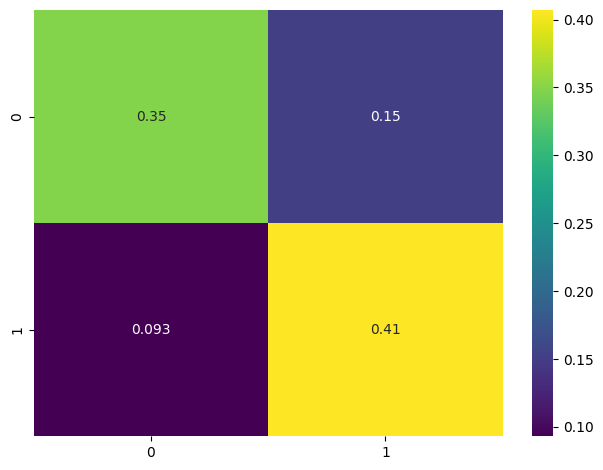

In [358]:
results_dict['SE-ResNet18'] = print_results(model, y_test, y_pred, y_pred_proba)

## Grad-CAM

In [118]:
gradcam_loader = DataLoader(dataset = test_dataset, batch_size = 1, shuffle = True)

In [119]:
def get_grad_cam(net, test_example, target_layer="layer4"):
    """
    Compute Grad-CAM heatmaps per lead for a given test example.

    Args:
        net (torch.nn.Module): The neural network model.
        test_example (tuple): A tuple containing (signal, _, age, gender, handcrafted).
        target_layer (str): The name of the target convolutional layer for Grad-CAM.

    Returns:
        np.ndarray: A 2D array of shape (num_leads, signal_length) containing heatmaps per lead.
    """
    # Unpack the test example
    signal, _, age, gender, handcrafted = test_example

    # Set the model to evaluation mode
    net.eval()

    # Move data to GPU if available
    device = next(net.parameters()).device  # Automatically get device (CPU or GPU)
    signal = signal.to(device)
    demographic = torch.stack((age, gender), dim=1).to(device)
    handcrafted = handcrafted.to(device)

    # Ensure gradients are enabled for the target layer
    net.zero_grad()

    # Forward pass
    pred = net(signal, demographic, handcrafted)  # Shape: (batch_size, num_classes)

    # Get the predicted class for each instance in the batch
    pred_class = pred.argmax(dim=1)  # Shape: (batch_size,)

    # Compute the loss for the predicted class
    # Use gather to select the scores corresponding to the predicted classes
    loss = pred.gather(1, pred_class.unsqueeze(1)).squeeze()

    # Backward pass to compute gradients
    loss.backward(retain_graph=True)

    # Retrieve gradients and activations from the target layer
    gradients = net.get_activations_gradient(target_layer)  # Shape: (batch_size, channels, time)
    activations = net.get_activations(target_layer)[0].detach()  # Shape: (batch_size, channels, time)

    # Check if gradients and activations are available
    if gradients is None or activations is None:
        raise ValueError(f"Gradients or activations not found for layer '{target_layer}'. "
                         "Ensure that hooks are correctly registered.")

    # Global average pooling of gradients over the time dimension to get weights per channel
    pooled_gradients = torch.mean(gradients, dim=2, keepdim=True)  # Shape: (batch_size, channels, 1)

    # Multiply each channel in the activations by the corresponding weights
    weighted_activations = activations * pooled_gradients  # Shape: (batch_size, channels, time)

    # Apply ReLU to the weighted activations
    heatmaps = F.relu(weighted_activations)  # Shape: (batch_size, channels, time)

    # Normalize each heatmap per channel
    # Add a small epsilon to prevent division by zero
    epsilon = 1e-8
    heatmaps = heatmaps / (heatmaps.view(heatmaps.size(0), heatmaps.size(1), -1).max(dim=2, keepdim=True).values + epsilon)

    # Rescale heatmaps to match the original signal length
    original_length = signal.shape[-1]  # Should be 4096
    heatmaps = F.interpolate(heatmaps, size=original_length, mode="linear", align_corners=False)  # Shape: (batch_size, channels, original_length)

    # Convert heatmaps to CPU and NumPy for further processing or visualization
    heatmaps = heatmaps.cpu().numpy()  # Shape: (batch_size, channels, original_length)

    # Since we typically handle one example at a time, squeeze the batch dimension
    heatmaps = heatmaps.squeeze(0)  # Shape: (channels, original_length)

    # Step 2: Map Activation Channels to Leads
    # Retrieve the first convolutional layer's weights
    first_conv_weights = net.conv1.weight.detach().cpu().numpy()  # Shape: (out_channels, in_channels, kernel_size)
    # Compute absolute mean across kernel size to get influence per input channel
    lead_importance = np.mean(np.abs(first_conv_weights), axis=2)  # Shape: (out_channels, in_channels)
    # Now, aggregate the activation channel heatmaps to leads using lead_importance
    # For each lead, compute a weighted sum of all activation channels based on their influence
    # This results in (in_channels, original_length)
    lead_heatmaps = np.dot(lead_importance.T, heatmaps)  # Shape: (in_channels, original_length)

    # Normalize lead heatmaps
    lead_heatmaps /= (lead_heatmaps.max(axis=1, keepdims=True) + 1e-8)  # Shape: (in_channels, original_length)

    return lead_heatmaps  # Shape: (num_leads, signal_length)

In [120]:
def visualize_signal(signal, heatmap, leads, sampling_freq=400, title=None):
    # Check the shape of the heatmap
    if heatmap.ndim != 2 or heatmap.shape[0] != len(leads):
        raise ValueError("Heatmap should be a 2D array with shape (num_leads, time).")

    # Use a colormap to map importance to colors
    colormap = matplotlib.colormaps['viridis']

    # Plot the original signal using wfdb
    fig = wfdb.plot_items(signal, figsize=(16, 8), sig_name=leads, sampling_freq=sampling_freq, time_units='samples', return_fig=True, title=title)

    # Overlay the heatmap using matplotlib
    for i, lead in enumerate(leads):
        ax = fig.axes[i]  # Get the correct axis for each lead
        ax.imshow(
            heatmap[i][np.newaxis, :],  # Add a new axis for the colormap
            cmap='viridis',
            alpha=1,  # Adjust transparency for shadow effect
            extent=(0, signal.shape[0], min(signal[:, i]), max(signal[:, i])),  # Align with signal's time and amplitude
            aspect='auto'
        )

    # Add a colorbar
    sm = matplotlib.cm.ScalarMappable(cmap='viridis')
    sm.set_array([])
    plt.colorbar(sm, ax=fig.axes, label='Importance')

    plt.show()

In [121]:
model.gradients.keys()

dict_keys([])

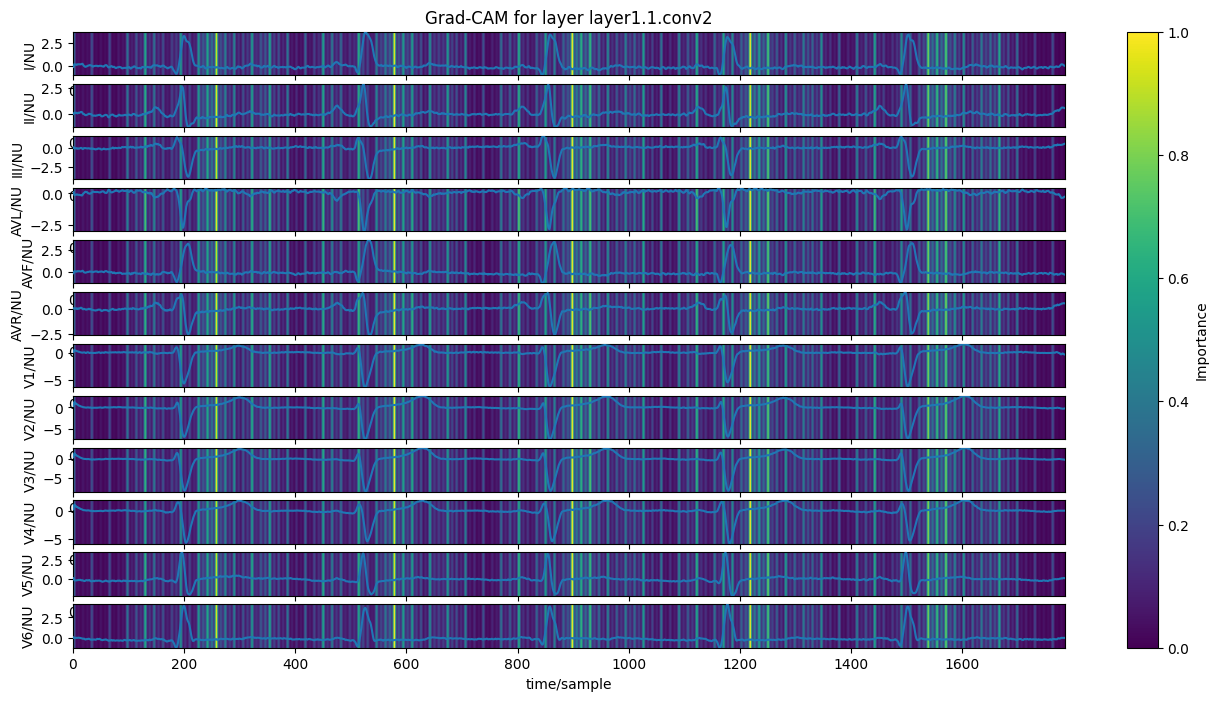

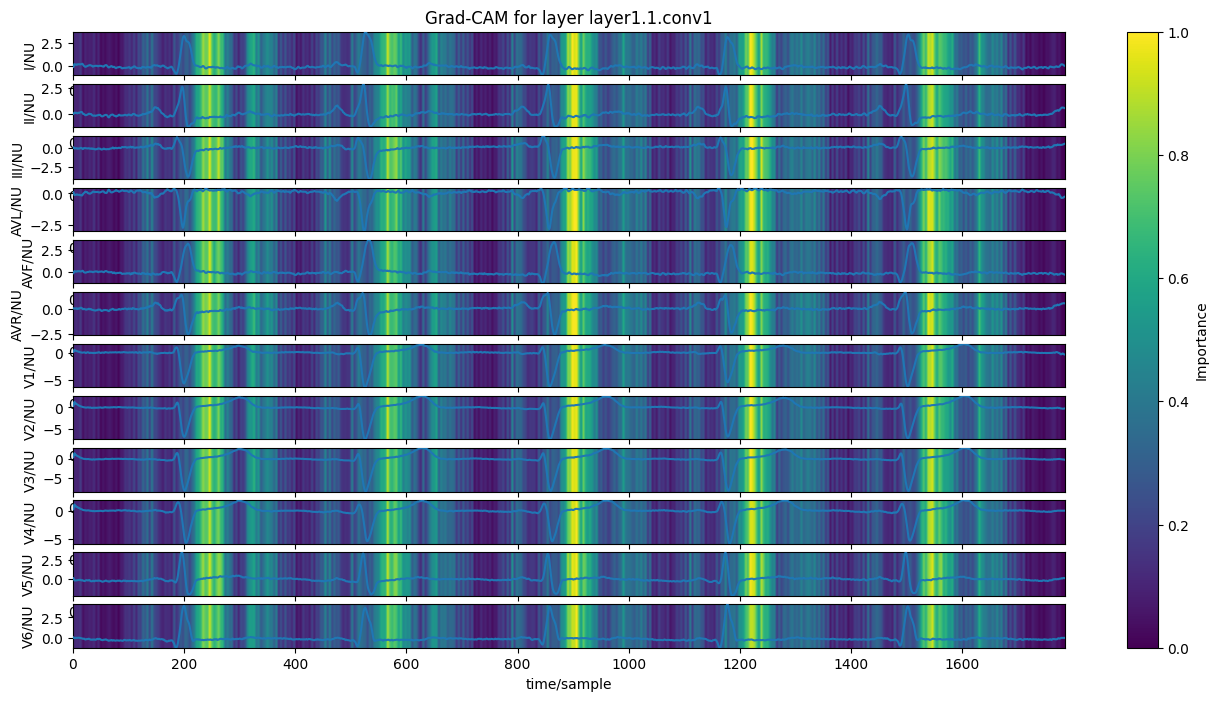

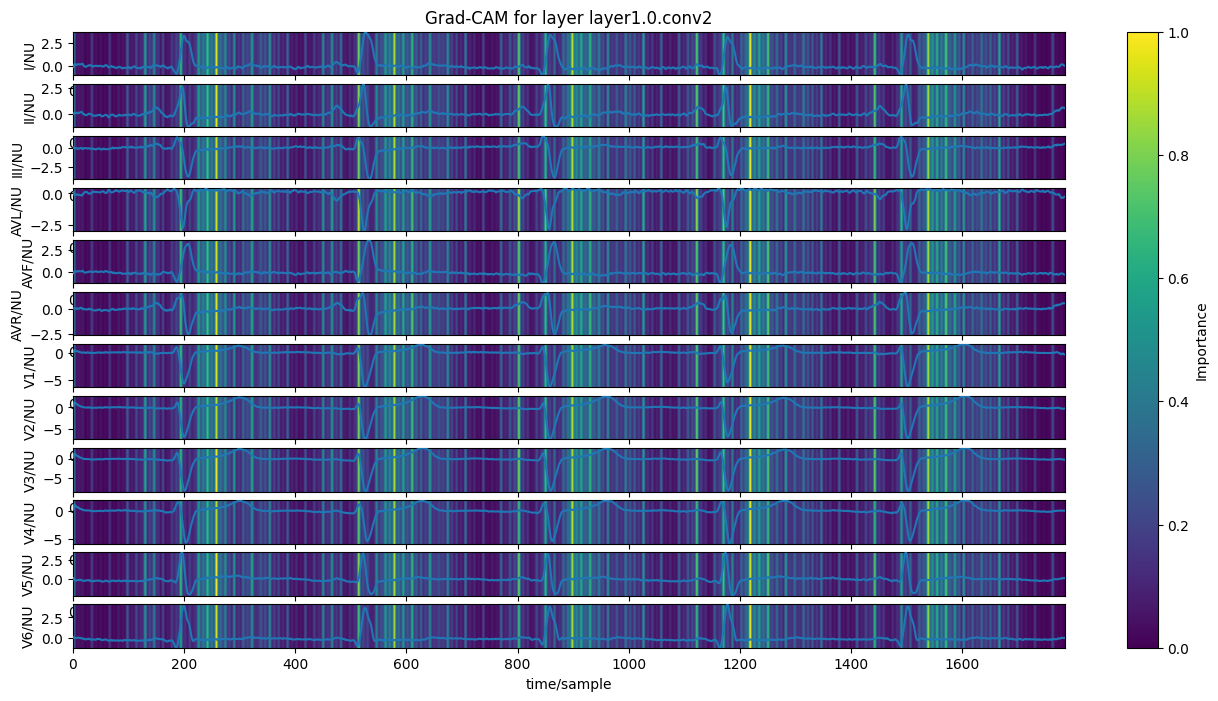

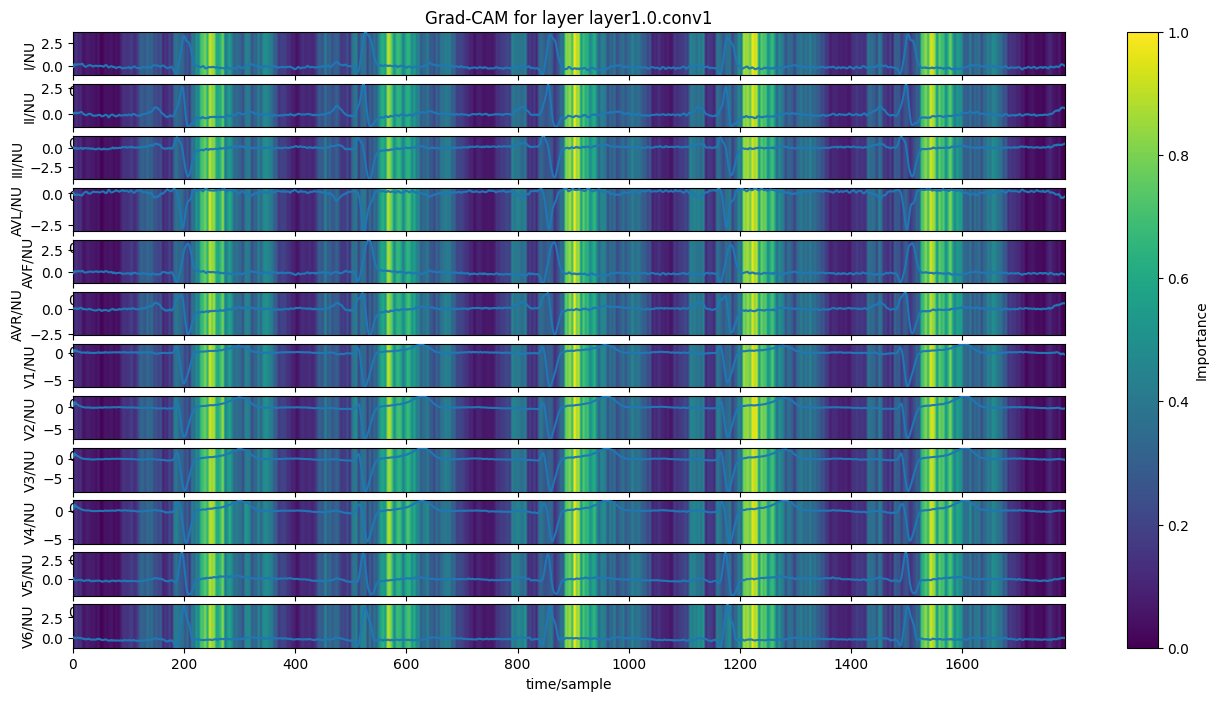

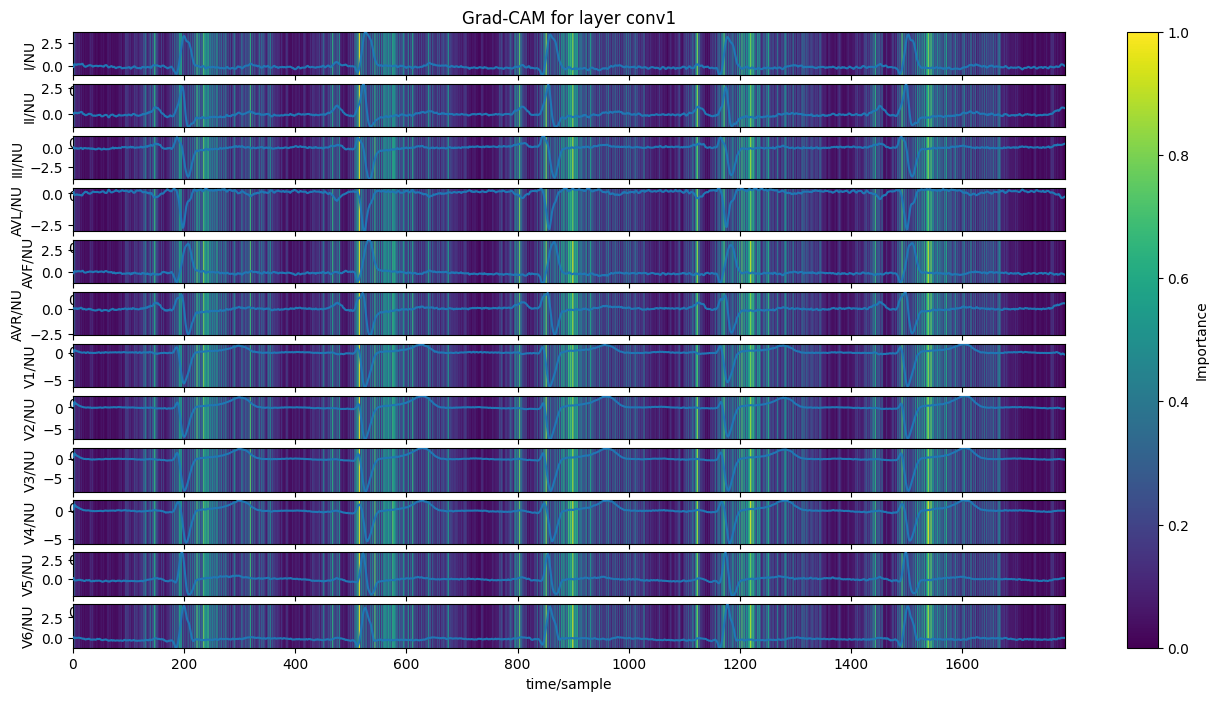

In [124]:
example = next(iter(gradcam_loader))
signal = example[0].squeeze(0).transpose(0, 1).cpu().numpy()
leads = ['I', 'II', 'III', 'AVL', 'AVF', 'AVR', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
layers = ['layer1.1.conv2', 'layer1.1.conv1', 'layer1.0.conv2', 'layer1.0.conv1', 'conv1']
for layer in layers:
    heatmap = get_grad_cam(net=model, test_example=example, target_layer=layer)
    visualize_signal(signal, heatmap, leads, sampling_freq=400, title=f"Grad-CAM for layer {layer}")

---

# Transformers

In [360]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):   
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # Add position encodings to embeddings
        # x: embedding vects, [B x L x d_model]
        x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)
        return self.dropout(x)

In [361]:
class Transformer(nn.Module):
    '''
    Transformer encoder processes convolved ECG samples
    Stacks a number of TransformerEncoderLayers
    '''
    def __init__(self, d_model, h, d_ff, num_layers, dropout):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.h = h
        self.d_ff = d_ff
        self.num_layers = num_layers
        self.dropout = dropout
        self.pe = PositionalEncoding(d_model, dropout=0.1)
        
        encode_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.h, 
            dim_feedforward=self.d_ff, 
            dropout=self.dropout)
        self.transformer_encoder = nn.TransformerEncoder(encode_layer, self.num_layers)
            
    def forward(self, x):
        out = x.permute(0, 2, 1)
        out = self.pe(out)
        out = out.permute(1, 0, 2)
        out = self.transformer_encoder(out)
        out = out.mean(0) # global pooling
        return out

In [362]:
# 15 second model
class CTN(nn.Module):
    def __init__(self, d_model, nhead, d_ff, num_layers, dropout_rate, deepfeat_sz):
        super(CTN, self).__init__()
        
        self.encoder = nn.Sequential( # downsampling factor = 20
            nn.Conv1d(12, 128, kernel_size=14, stride=3, padding=2, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, kernel_size=14, stride=3, padding=0, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True)
        )
        self.transformer = Transformer(d_model, nhead, d_ff, num_layers, dropout=0.1)
        self.fc1 = nn.Linear(d_model, deepfeat_sz)
        self.fc2 = nn.Linear(deepfeat_sz, 1)  # Output only one neuron
        self.dropout = nn.Dropout(dropout_rate)
            
        def _weights_init(m):
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        #self.apply(_weights_init)
            
    def forward(self, x):
        z = self.encoder(x)          # encoded sequence is batch_sz x nb_ch x seq_len
        out = self.transformer(z)    # transformer output is batch_sz x d_model
        out = self.dropout(F.relu(self.fc1(out)))
        out = self.fc2(out)  # No concatenation with wide_feats
        return out

In [363]:
#Parameters
model_parameters = {
    "d_model": 256,
    "nhead" : 8,
    "d_ff" : 2048,
    "num_layers" : 8,
    "dropout_rate" : 0.2,
    "deepfeat_sz" : 64
}

learning_rate = 1e-4
weight_decay = 1e-3

In [364]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CTN(**model_parameters)
model.to(device)

# Positive class weight
pos_weight = (y==0.).sum()/y.sum()

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

In [136]:
model_name = 'ctn_transformer_model.pth'

In [ ]:
model = train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=False, with_handcrafted=False)

In [ ]:
model = CTN(**model_parameters)
model.to(device)

model.load_state_dict(torch.load(model_name, weights_only = True))

In [ ]:
y_pred, y_pred_proba = evaluate_model(model, test_dloader, device, with_demographic=False, with_handcrafted=False)

In [ ]:
results_dict['CTN'] = print_results(model, y_test, y_pred, y_pred_proba)

## Model 2 - custom optimizer

In [139]:
class NoamOpt:
    "Optim wrapper that implements rate."
    def __init__(self, model_size, factor, warmup, optimizer):
        self.optimizer = optimizer
        self._step = 0
        self.warmup = warmup
        self.factor = factor
        self.model_size = model_size
        self._rate = 0
        
    def step(self):
        "Update parameters and rate"
        self._step += 1
        rate = self.rate()
        for p in self.optimizer.param_groups:
            p['lr'] = rate
        self._rate = rate
        self.optimizer.step()
        
    def rate(self, step = None):
        "Implement `lrate` above"
        if step is None:
            step = self._step
        return self.factor * \
            (self.model_size ** (-0.5) *
            min(step ** (-0.5), step * self.warmup ** (-1.5)))
        
def get_std_opt(model):
    return NoamOpt(model_parameters['d_model'], 2, 4000,
            torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))

In [ ]:
if 'model' in locals():
    del model

with torch.no_grad():
    torch.cuda.empty_cache()

gc.collect()

In [ ]:
model = CTN(**model_parameters)
model.to(device)

optimizer = NoamOpt(model_parameters['d_model'], 1, 4000, torch.optim.Adam(model.parameters(), lr=0, betas=(0.9, 0.98), eps=1e-9))
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer.optimizer, mode='min', factor=0.1, patience=10)

In [ ]:
model_name = 'noam_transformer_model.pth'    

In [ ]:
model = train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=False, with_handcrafted=False)

In [ ]:
model = CTN(**model_parameters)
model.to(device)

model.load_state_dict(torch.load(model_name, weights_only = True))

In [ ]:
y_pred, y_pred_proba = evaluate_model(model, test_dloader, device, with_demographic=False, with_handcrafted=False)

In [ ]:
results_dict['Noam'] = print_results(model, y_test, y_pred, y_pred_proba)

## Model 3 - use also age and sex

In [ ]:
class PositionalEncoding(nn.Module):
    "Implement the PE function."
    def __init__(self, d_model, dropout, max_len=5000):   
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        # Add position encodings to embeddings
        # x: embedding vects, [B x L x d_model]
        x = x + Variable(self.pe[:, :x.size(1)], requires_grad=False)
        return self.dropout(x)

class Transformer(nn.Module):
    '''
    Transformer encoder processes convolved ECG samples
    Stacks a number of TransformerEncoderLayers
    '''
    def __init__(self, d_model, h, d_ff, num_layers, dropout):
        super(Transformer, self).__init__()
        self.d_model = d_model
        self.h = h
        self.d_ff = d_ff
        self.num_layers = num_layers
        self.dropout = dropout
        self.pe = PositionalEncoding(d_model, dropout=0.1)
        
        encode_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model, 
            nhead=self.h, 
            dim_feedforward=self.d_ff, 
            dropout=self.dropout)
        self.transformer_encoder = nn.TransformerEncoder(encode_layer, self.num_layers)
            
    def forward(self, x):
        out = x.permute(0, 2, 1)
        out = self.pe(out)
        out = out.permute(1, 0, 2)
        out = self.transformer_encoder(out)
        out = out.mean(0) # global pooling
        return out

class CTN(nn.Module):
    def __init__(self, d_model, nhead, d_ff, num_layers, dropout_rate, deepfeat_sz):
        super(CTN, self).__init__()
        
        self.encoder = nn.Sequential( # downsampling factor = 20
            nn.Conv1d(12, 128, kernel_size=14, stride=3, padding=2, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Conv1d(128, 256, kernel_size=14, stride=3, padding=0, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Conv1d(256, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=2, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True),
            nn.Conv1d(d_model, d_model, kernel_size=10, stride=1, padding=0, bias=False),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True)
        )
        self.transformer = Transformer(d_model, nhead, d_ff, num_layers, dropout=0.1)
        self.fc1 = nn.Linear(d_model + 2, deepfeat_sz)  # +2 for age and sex
        self.fc2 = nn.Linear(deepfeat_sz, 1)  # Output only one neuron
        self.dropout = nn.Dropout(dropout_rate)
            
        def _weights_init(m):
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
        #self.apply(_weights_init)
            
    def forward(self, x, age, sex):
        z = self.encoder(x)          # encoded sequence is batch_sz x nb_ch x seq_len
        out = self.transformer(z)    # transformer output is batch_sz x d_model
        
        # Concatenate age and sex features
        age_sex = torch.cat([age.unsqueeze(1), sex.unsqueeze(1)], dim=1)
        out = torch.cat([out, age_sex], dim=1)
        
        out = self.dropout(F.relu(self.fc1(out)))
        out = self.fc2(out)  # No concatenation with wide_feats
        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CTN(**model_parameters)
model.to(device)

pos_weight = (y==0.).sum()/y.sum()

# Define loss function, optimizer, and scheduler
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight))
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

In [ ]:
model_name = 'demographic_transformer_model.pth'

In [ ]:
model = train_model(model, model_name, train_dloader, val_dloader, device, criterion, optimizer, scheduler, epochs, patience, with_demographic=True, with_handcrafted=False)

In [ ]:
model = CTN(**model_parameters)
model.to(device)

model.load_state_dict(torch.load(model_name, weights_only = True))

In [ ]:
y_pred, y_pred_proba = evaluate_model(model, test_dloader, device, with_demographic=True, with_handcrafted=False)

In [ ]:
results_dict['Demog-Transformer'] = print_results(model, y_test, y_pred, y_pred_proba)

In [140]:
pd.DataFrame(results_dict)

,Logistic Regression,XGBoost,SVC,KNN,SE-ResNet18
acc,0.682843,0.705006,0.716087,0.690103,0.756014
auc,0.745713,0.781293,0.779762,0.753267,0.845041
f1,0.672196,0.714497,0.718454,0.680331,0.769397
f_beta,0.686180,0.701118,0.715040,0.693618,0.745038
